# 2024 Spoken Wiki attentional word recognition task results

### Analysis is for main diotic experiment
### Models run on all combinations of stimuli
___

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle
import importlib 
import IPython.display as ipd
%matplotlib inline 
import h5py

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter

import src.util_process_prolific as up 
importlib.reload(up)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


<module 'src.util_process_prolific' from '/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/util_process_prolific.py'>





### Import human data

In [2]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
path_to_expmt_stim = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_word_recognition_all_conds/data/*.json"))

len(human_fnames)

428

## Process Human Results

In [3]:
## Get all subject data into one df for analysis

dfs = []
for fname in human_fnames:
    try:
        dfs.append(up.get_part_df_swc(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]

## Add snr and condition names as columns - unpack from file code in file names 

# get cond name map
map_path = path_to_expmt_stim / 'human_attn_expmt_cond_map.pkl' 
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)
stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

# add as columns 
results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(lambda x: up.get_stim_snr_and_cond(x, stim_cond_map=stim_cond_map)))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str].copy()
trial_results.rename(columns={"condition":"raw_condition"}, inplace=True)

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                       "babble":"background_cv08talkerbabble",
                       "stationary": "background_issnstationary",
                       "natural scene": "background_ieeeaaspcasa",
                       "clean": "SILENCE"}
# 1-talker conds preserved in replace below

condition_map = {v:k for k,v in test_condition_dict.items()}
trial_results['condition'] = trial_results['raw_condition'].replace(condition_map)

# screen based on completion 
total_trials = 196
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]
# Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')

# add shortened stim name field 
trial_results['stim_name'] = trial_results['stimulus'].str.split('/').str[-1].str.split('.').str[0]

# drop coluns in trial_results that are all nans 
trial_results = trial_results.dropna(axis=1, how='all')

Unterminated string starting at: line 1 column 84194 (char 84193)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_6658b1491e88ec15902d5301.json
Unterminated string starting at: line 1 column 192613 (char 192612)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_6174b049932ee98236563b51.json
Unterminated string starting at: line 1 column 72207 (char 72206)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_65dc99d0191a135ab835bf69.json
Unterminated string starting at: line 1 column 324626 (char 324625)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_5c0430c71a20110001e9b05a.json
Expecting ',' delimiter: line 1 column 204794 (char 204793)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_666883e7cd549b6798159085.json
Unterminated string starting at: line 1 column 60213

In [4]:
# catch_trial_particiapnt_performance
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()

print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response.isna())]
analysis_df = analysis_df.dropna(axis=1, how='all').dropna(axis=0, how='all')
# analysis_df.groupby('id_subject').condition.count()

N total participants  211
N good participants  198



#### Add re-scored performance based on entries included in excerpt transcripts  

In [5]:
### Make map from cv dictionary ixs to experiment word ixs 

## import cv maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


## import experiment word map
human_exp_word_key = pickle.load( open(path_to_expmt_stim / "human_attn_expmt_word_key.pkl", "rb" )) 
exp_word_2_class = {v:k for k,v in human_exp_word_key.items()}



In [6]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

manifests = pd.read_pickle(path_to_expmt_stim / "human_cue_target_distractor_df_w_meta_transcripts_w_f0.pdpkl")
# add columns for word int and stim name to map back to participant data 
manifests['word_fname_int'] = manifests['word'].replace(exp_word_2_class)
manifests['stim_name'] = manifests[['gender', 'word_fname_int']].apply(lambda row: f"{row.gender[0]}_{row.word_fname_int:03d}", axis=1)

cols_to_merge = ['stim_name',
                 'gender',
                 'word',
                 'target_f0',
                 'english_distractor_f0',
                 'mandarin_distractor_f0',
                 'dutch_distractor_f0',
                 'target_transcripts',
                 'same_sex_distractor_1_transcripts',
                 'diff_sex_distractor_1_transcripts',
                 "same_sex_dist_1_word",
                 "diff_sex_dist_1_word"
]

analysis_df = pd.merge(analysis_df,
                        manifests[cols_to_merge],
                                    left_on='stim_name', right_on='stim_name', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.same_sex_dist_1_word).astype('int')
analysis_df['accuracy'] = (analysis_df.response == analysis_df.word).astype('int')


# add adjusted accuracy and confusions 
pred_words = analysis_df.response.values
target_words = analysis_df.word.values
target_transcripts = analysis_df.target_transcripts.values
same_sex_distractor_words = analysis_df.same_sex_dist_1_word.values
diff_sex_distractor_words = analysis_df.diff_sex_dist_1_word.values
same_sex_distractor_transcripts = analysis_df.same_sex_distractor_1_transcripts.values
diff_sex_distractor_transcripts = analysis_df.diff_sex_distractor_1_transcripts.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not isinstance(target_transcript, float) else np.nan
                            for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                            ])

adjusted_confs = np.array([int(pred_word in same_sex_transcript or pred_word in diff_sex_transcript or pred_word == same_sex_word or pred_word == diff_sex_word)
                            if not (isinstance(same_sex_transcript, float) and isinstance(diff_sex_transcript, float)) else np.nan
                            for pred_word, same_sex_word, diff_sex_word, same_sex_transcript, diff_sex_transcript in zip(pred_words, same_sex_distractor_words, diff_sex_distractor_words,  same_sex_distractor_transcripts, diff_sex_distractor_transcripts)
                            ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

## Remap 1-talker distractor names accordingly 

analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'sex_cond'] = analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'].str.split('-').str[-1].str.title()
analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'dist_lang'] = analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'].str.split('-').str[-2].str.title()

def remap_1_distractor_str(cond_str):
    if 'english' in cond_str:
        return '1-talker'
    if 'mandarin' in cond_str:
        return "Mandarin distractor"
    if 'dutch' in cond_str:
        return "Dutch distractor"

analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'] = analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'].apply(remap_1_distractor_str)
analysis_df = analysis_df[analysis_df.condition != 'catch_trial']



In [7]:
to_check = analysis_df[analysis_df.condition!="catch_trial"]
(to_check.adjusted_accuracy >= to_check.accuracy).all()

True

In [8]:
analysis_df.condition.unique()

array(['stationary', 'Mandarin distractor', 'natural scene', 'clean',
       'Dutch distractor', '1-talker', 'babble', '2-talker', '4-talker',
       'music'], dtype=object)

In [9]:
##########################
# Make df for f0 analysis 
##########################

# drop unwanted conditions
f0_analysis_df = analysis_df[analysis_df.condition.isin([ "1-talker", 'Mandarin distractor', 'Dutch distractor', 'clean'])].copy()

# cut and remove language-specific f0 columns - just make distractor f0 
f0_analysis_df.loc[f0_analysis_df.dist_lang == 'English', 'distractor_f0'] = f0_analysis_df.loc[f0_analysis_df.dist_lang == 'English', 'english_distractor_f0'].values
f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Mandarin', 'distractor_f0'] = f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Mandarin', 'mandarin_distractor_f0'].values
f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Dutch', 'distractor_f0'] = f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Dutch', 'dutch_distractor_f0'].values

f0_analysis_df["abs_f0_diff"] = np.abs(f0_analysis_df.target_f0 - f0_analysis_df.distractor_f0)
f0_analysis_df["percent_f0_diff"] = f0_analysis_df.distractor_f0 / f0_analysis_df.target_f0 
def get_f0_ratio(row):
    return max(row.target_f0, row.distractor_f0) / min(row.target_f0, row.distractor_f0)
f0_analysis_df["f0_ratio"] = f0_analysis_df.apply(get_f0_ratio, axis=1)

# # rename condition to background condition
f0_analysis_df = f0_analysis_df.rename(columns={"condition": "background_condition"})
f0_analysis_df = f0_analysis_df.dropna(axis=1,  how = 'all')
# get columns with trial in their name
cols_to_drop = [col for col in f0_analysis_df.columns if 'trial' in col ]
# drop prolific meta columns
f0_analysis_df = f0_analysis_df.drop(columns=cols_to_drop).reset_index(drop=True)


In [10]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(["snr", 'id_subject', "condition"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


In [11]:
## Summarize participant data for aggregate plotting

summary_df = part_summary_df.groupby(['snr', 'condition']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
summary_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']


In [12]:
# summary_df.to_pickle('2023_swc_attn_word_rec_prolific_summary_n_81.pdpkl')

## Load Model Results 

In [13]:
!ls {path_to_expmt_stim}

dutch_1_distractor_f0_manifest.pdpkl
english_1_distractor_f0_manifest.pdpkl
full_cue_target_distractor_df_w_meta.pdpkl
full_cue_target_distractor_df_w_meta_bad.pdpkl
full_cue_target_distractor_df_w_meta_paths.pdpkl
full_cue_target_distractor_df_w_meta_transcripts.pdpkl
human_attn_expmt_cond_map.pkl
human_attn_expmt_word_key.js
human_attn_expmt_word_key.pkl
human_cue_target_distractor_df_w_meta_transcripts.pdpkl
human_cue_target_distractor_df_w_meta_transcripts_w_f0.pdpkl
mandarin_1_distractor_f0_manifest.pdpkl
model_eval_stim.h5
old_sounds
sounds
test_stim_orig_manifest.pdpkl
threshold_experiment_sounds.tar.gz


In [14]:
## import class maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}

### Get conditions 
cond_map = pickle.load( open(path_to_expmt_stim / "human_attn_expmt_cond_map.pkl", "rb" )) 
conds = set([cond for cond,snr in cond_map.values()])

test_cond_to_human = {v:k for k,v in test_condition_dict.items()}
cond_remap = {}
for cond in conds:
    if cond in test_cond_to_human:
        cond_remap[cond] = test_cond_to_human[cond]
    else:
        cond_remap[cond] = cond 
cond_remap['natural scene'] = 'natural scene'


In [55]:

model_names = [ "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout", "word_task_v09_cue_loc_task"] #"word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout"]# "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned"]
             
model_name_dict = {
                   'word_task_v08_control_no_attn': 'Baseline CNN',
                   "word_task_gender_balanced_fc_1024_v08": "Gender Balanced large fc v08",
                   "word_task_half_co_loc_v08_gender_bal": "Gender Balanced v08",
                   "word_task_half_co_loc_v08_gender_bal_4M": "Gender Balanced v08 4M",
                   "word_task_half_co_loc_v08_gender_bal_4M_orig": "50% co-located v08 4M",
                   "word_task_half_co_loc_v08_gender_bal_4M_sanity": "50% co-located GB v08 4M",
                   "word_task_deep_fc_1024_v08": "Deeper Architecture",
                   "word_task_half_co_locate_deep_fc_1024_v08": "Deep Arch. 50% co-located",
                   "word_task_half_co_locate_deep_fc_1024_v08_old": "Deep Arch. 50% co. old ckpt",
                   "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned": "learned no cue trials",
                   "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout": "Feature-gain model",
                   "word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout": "learned no cue good SNR",
                   "word_task_v09_cue_loc_task": "Dual Task",
                  }




all_model_results = []
all_model_f0_results = []

background_conditions = summary_df.background_condition.unique() 
str_to_cond = {v:k for k,v in test_condition_dict.items()}

## preselect manifest columns 
cols_to_merge = [
                #  'stim_name',
                 'gender',
                 'word',
                 'word_int',
                 'target_f0',
                 'english_distractor_f0',
                 'mandarin_distractor_f0',
                 'dutch_distractor_f0',
                 'target_transcripts',
                 'same_sex_distractor_1_transcripts',
                 'diff_sex_distractor_1_transcripts',
                 "same_sex_dist_1_word",
                 "diff_sex_dist_1_word"

]

manifests['word_int'] = manifests.word.replace(cv_word_2_class)
model_manifest = manifests[cols_to_merge].sort_values(['gender', 'word']).copy()
model_manifest['df_index'] = model_manifest.index

# update gt manifests to match readable format 
for model_name in model_names:
    output_paths = list(Path(f'swc_2024_eval_full_stim/{model_name}').glob('*.csv'))
    print(len(output_paths))
    results_dfs = []

    for path in output_paths:
        try:
            df = pd.read_csv(path)
            # reformat dict
            df['model'] = path.parent.name
            #parts of name 
            parts = path.stem.split(path.parent.name)[-1].split('_')   
            # if 'stim_tag' in df.columns:
            #     # rename 
            #     df.rename(columns={'stim_tag':'stim_name'}, inplace=True)
            # use re to split path.stem after model name and before <int>dB 
            df['background_condition'] = [v for v in cond_remap.values() if "_".join(v.split(' ')) in path.stem][0]
            if 'clean' in path.stem:
                df['background_condition'] = 'clean'
                df['snr'] =  'inf' # really np.inf, 6 for plotting 
            else:
                df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))

            df['test_index'] = df.index
            df = pd.merge(df,
                model_manifest,
                            left_on=["test_index", "true_word_int"], right_on=["df_index", "word_int"])

            results_dfs.append(df)
        except Exception as e:
            print(e)
            print(path)


    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    model_str = model_name_dict[model_name]
    model_results['group'] = model_str
    ## Load in model vocab 
    model_results['pred_word'] = model_results['pred_word_int'].replace(cv_class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(cv_class_2_word)


    # Add 1-talker condition metadata to model results

    # add confusions 
    model_results['confusions'] = (model_results.pred_word == model_results.same_sex_dist_1_word).astype('int')

    # add adjusted accuracy and confusions 
    pred_words = model_results.pred_word.values
    target_words = model_results.word.values
    target_transcripts = model_results.target_transcripts.values
    same_sex_distractor_words = model_results.same_sex_dist_1_word.values
    diff_sex_distractor_words = model_results.same_sex_dist_1_word.values
    same_sex_distractor_transcripts = model_results.same_sex_distractor_1_transcripts.values
    diff_sex_distractor_transcripts = model_results.diff_sex_distractor_1_transcripts.values


    adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                                if not isinstance(target_transcript, float) else np.nan
                                for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                                ])

    adjusted_confs = np.array([int(pred_word in same_sex_transcript or pred_word in diff_sex_transcript or pred_word == same_sex_word or pred_word == diff_sex_word)
                                if not (isinstance(same_sex_transcript, float) and isinstance(diff_sex_transcript, float)) else np.nan
                                for pred_word, same_sex_word, diff_sex_word, same_sex_transcript, diff_sex_transcript in zip(pred_words, same_sex_distractor_words, diff_sex_distractor_words,  same_sex_distractor_transcripts, diff_sex_distractor_transcripts)
                                ])
    
    model_results['adjusted_accuracy'] = adjusted_acc
    model_results['adjusted_confusions'] = adjusted_confs
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'sex_cond'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].str.split('-').str[-1].str.title()
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'dist_lang'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].str.split('-').str[-2].str.title()
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].apply(remap_1_distractor_str)

    
    all_model_results.append(model_results)


    model_f0_df = model_results[model_results.background_condition.isin([ "1-talker", 'Mandarin distractor', 'Dutch distractor', 'clean'])].copy()
    model_f0_df.loc[model_f0_df.dist_lang == 'English', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'English', 'english_distractor_f0'].values
    model_f0_df.loc[model_f0_df.dist_lang == 'Mandarin', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'Mandarin', 'mandarin_distractor_f0'].values
    model_f0_df.loc[model_f0_df.dist_lang == 'Dutch', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'Dutch', 'dutch_distractor_f0'].values
    model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df["percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    model_f0_df["f0_ratio"] = model_f0_df.apply(get_f0_ratio, axis=1)
    model_f0_df.loc[:, "abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df.loc[:, "percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    all_model_f0_results.append(model_f0_df)

all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
all_model_f0_results = pd.concat(all_model_f0_results, axis=0, ignore_index=True)

61
61


In [56]:
# Adjusted accuracy should always greater than or equal to accuracy
(all_model_results['adjusted_accuracy'] >= all_model_results['accuracy']).all() 

True

In [57]:
all_model_results.snr.unique()

array([-3, -6, -9, 0, 3, 'inf'], dtype=object)

In [58]:
N = int(summary_df.N.unique().item())

summary_df['group'] = f'Participants (N={N})'
model_results['group'] = model_results['group']
# all_model_results = all_model_results[all_model_results.snr > -12]
# combine model and participant results ignore missing columns
combined_results = pd.concat([summary_df, all_model_results], axis=0, ignore_index=True)

In [59]:
combined_results.loc[combined_results.snr == np.inf, 'snr'] = 6
combined_results.loc[combined_results.snr == 'inf', 'snr'] = 6
combined_results.snr = combined_results.snr.astype('int')
combined_results = combined_results[combined_results.snr > -12]

In [60]:
all_model_results.group.unique()

array(['Feature-gain model', 'Dual Task'], dtype=object)

## Standard analysis 

(0.0, 1.0)

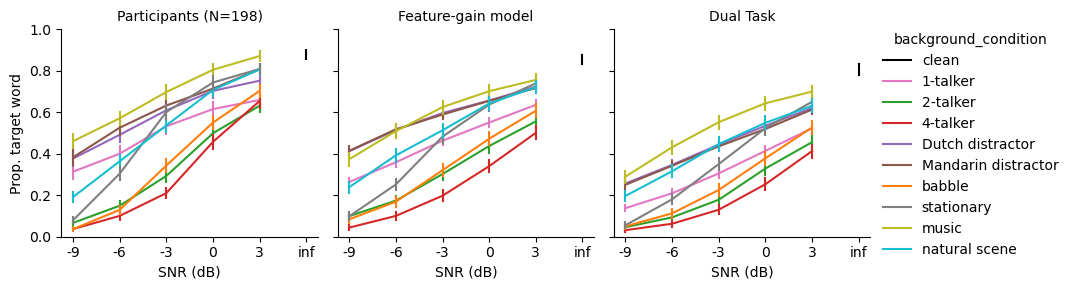

In [61]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

# hue_order = summary_df.background_condition.unique()
hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'Dutch distractor', 'Mandarin distractor', 'babble', 'stationary', 'music', 'natural scene',]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))
palette['clean'] = 'k'
palette['1-talker'] = '#e377c2'
palette['babble'] = 'tab:orange'
# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='adjusted_accuracy', col='group', hue='background_condition', hue_order=hue_order, #col_wrap=4,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"], 
                  kind='line', marker='', palette=palette, height=3, aspect=1, err_style='bars', errorbar=('se', 2))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Prop. target word")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    if model != f"Participants (N={N})":
        continue 
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        selected['adj_acc_std_error'] = selected['adj_acc_std_error'] * 2 
        ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)
# plt.suptitle(f"Using in-transcript accuracy", y=1.05)
# plt.tight_layout()

In [62]:
to_plot.model.unique()

array([nan,
       'word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout',
       'word_task_v09_cue_loc_task'], dtype=object)

In [23]:
to_plot[ (to_plot.background_condition == '1-talker') & (to_plot.snr == 0)].groupby(['group']).adjusted_accuracy.mean() # (to_plot.model=='word_task_25p_loc_v07_LN_last_valid_time_no_affine') &

group
50% co-located GB v08 4M    0.563012
Dual Task                   0.413934
Participants (N=198)        0.615620
learned no cue              0.550717
Name: adjusted_accuracy, dtype: float64

/tmp/ipykernel_673740/1445610373.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected['adj_acc_std_error'] = selected['adj_acc_std_error'] * 2
/tmp/ipykernel_673740/1445610373.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected['adj_conf_std_error'] = selected['adj_conf_std_error'] * 2


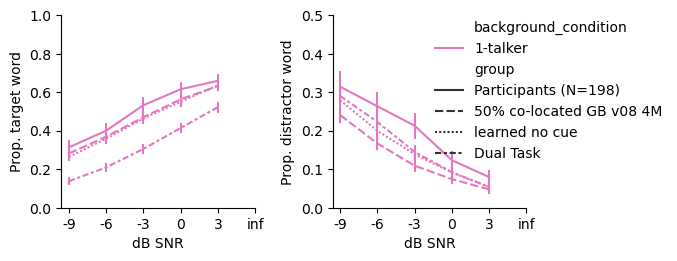

In [24]:
fig, axs = plt.subplots(1,2, figsize=(6,2.5))

to_plot = combined_results[combined_results.background_condition.isin(["1-talker"])]
# to_plot = to_plot.drop(columns=['target_transcript', 'distractor_transcript'])
# to_plot.drop_duplicates(inplace=True)

style_order = to_plot.group.unique()

# style_order = ['participants (N=81)', 'Diotic CommonVoice', 'Mono CommonVoice', 'Mono WordSpeakerNoise', 'Binaural CommonVoice', "Binaural Half-CoLocated CV"]


g1 = sns.lineplot(data=to_plot, x = 'snr', y = 'adjusted_accuracy',  err_style='bars', errorbar=('ci', 95),
                   style='group',style_order=style_order, 
                   hue='background_condition', palette=palette,
            ax=axs[0])

g2 = sns.lineplot(data=to_plot, x = 'snr', y = 'adjusted_confusions',  err_style='bars', errorbar=('ci', 95),
                   style='group',style_order=style_order, 
                   hue='background_condition', palette=palette,
            ax=axs[1])

# add error bars for participants
# iterate through each facet of the facetgrid
# select the data for each hue group
selected = to_plot[(to_plot['group'].eq(f'Participants (N={N})')) & (to_plot['background_condition'].eq('1-talker'))]
selected['adj_acc_std_error'] = selected['adj_acc_std_error'] * 2
selected['adj_conf_std_error'] = selected['adj_conf_std_error'] * 2
g1.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette["1-talker"], marker=None, ls='none' )
g2.errorbar(data=selected, x="snr", y="adjusted_confusions", yerr="adj_conf_std_error", color=palette["1-talker"], marker=None, ls='none' )


g1.set_xticks(ticks=x_tick_locs) # set new labels
g2.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticklabels(labels=x_tick_labels)
g2.set_xticklabels(labels=x_tick_labels)
g1.set_ylim(0,1)
g2.set_ylim(0,.5)

g1.legend().remove()     
# g2.legend().remove()

# add space between plots
plt.subplots_adjust(wspace=0.4)
sns.despine()

# remove legend titles 
g2.legend_.set_title('')
axs[0].set_xlabel("dB SNR")
axs[1].set_xlabel("dB SNR")

axs[0].set_ylabel("Prop. target word")
axs[1].set_ylabel("Prop. distractor word")

# remove last element from legend 
handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(handles[:-1], labels[:-1], frameon=False, bbox_to_anchor=(0.5, 1), loc=2, borderaxespad=0., title='')

### Scatter plot of human vs model performance

In [25]:
from scipy import stats


50% co-located GB v08 4M


Text(0.5, 0.95, 'Humans vs Model (50% co-located GB v08 4M)')

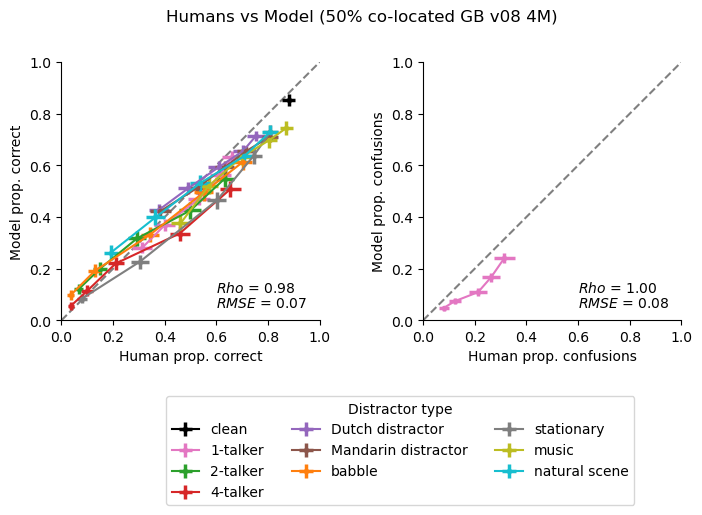

In [26]:
grouped_results = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

# hue_order = summary_df.background_condition.unique()
hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'Dutch distractor', 'Mandarin distractor', 'babble', 'stationary', 'music', 'natural scene',]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))
palette['clean'] = 'k'
palette['1-talker'] = '#e377c2'
palette['babble'] = 'tab:orange'

x = y = np.linspace(0,1,6)


fontsize = 10

# model_list = ["Binaural CommonVoice", "Binaural Half-CoLocated CV", 'Mono CommonVoice', 'Diotic CommonVoice', 'Mono WordSpeakerNoise']
model_list =['50% co-located GB v08 4M'] # grouped_results.group.unique()[1:]

# fig, axs = plt.subplots(2,len(model_list), figsize=((4*len(model_list)),8))
x_size, y_size = 8, 4
fig, axs = plt.subplots(1,2, figsize=((x_size*len(model_list)),y_size))


# for ix, group in enumerate(grouped_results.group.unique()):
# add dashed line to each subplot 
for ax in axs.flat:
    ax.plot(x,y, ls='dashed', color='grey')

human_df = grouped_results[grouped_results.group.str.contains('Participants')]
# get adjusted_confusion data
human_conf_data = human_df[human_df.background_condition ==  "1-talker"]
human_conf_means = human_conf_data["adjusted_confusions"].values
human_conf_errors = human_conf_data["adj_conf_std_error"].values * 2 # 95% CI

for ix, model in enumerate(model_list):
    print(model)
    model_df = grouped_results[grouped_results.group == model]
    # summarize model data
    model_df = model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem'], 
                                                                        'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    

    for condition in hue_order:
        # print(condition)
        # plot acc 
        human_data = human_df[human_df.background_condition == condition]
        human_means = human_data["adjusted_accuracy"].values
        human_errors = human_data["adj_acc_std_error"].values * 2 # 95% CI

        model_data = model_df[model_df.background_condition == condition]
        model_means = model_data["adjusted_accuracy"].values
        model_errors = model_data["adj_acc_std_error"].values * 2 # 95% CI

        axs[0].errorbar(x=human_means, y=model_means, xerr=human_errors, yerr=model_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= condition,
                            color=palette[condition])#, mfc=palette[condition], mec=palette[condition])


    # model adjusted_confusions
    model_conf_data = model_df[model_df.background_condition ==  "1-talker"]
    model_conf_means = model_conf_data["adjusted_confusions"].values
    model_conf_errors = model_conf_data["adj_conf_std_error"].values * 2 # 95% CI 

    axs[1].errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors, yerr=model_conf_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                        color=palette[ "1-talker"])
    
    # Add error annotations 
    # acc errors 
    res = stats.spearmanr(human_df["adjusted_accuracy"].values,  model_df['adjusted_accuracy'].values)
    rho = res.correlation
    axs[0].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    samp_rmse = np.sqrt(np.mean((human_df["adjusted_accuracy"].values - model_df['adjusted_accuracy'].values)**2))
    axs[0].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)
    # conf errors
    res = stats.spearmanr(human_conf_means, model_conf_means)
    rho = res.correlation
    axs[1].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    samp_rmse = np.sqrt(np.mean((human_conf_means - model_conf_means)**2))
    axs[1].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
    # axs[0].set_title(model, fontsize=fontsize)
    axs[0].set_xlabel(f"Human prop. correct", fontsize=fontsize)
    axs[1].set_xlabel(f"Human prop. confusions", fontsize=fontsize)

    
# set first row x and y limits to 0 1 and have same tick values 
for ax in axs.flat:
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_xticks(x)
    ax.set_yticks(y)

# for ax in axs.flat:
#     ax.set_xlim(0,1)
#     ax.set_ylim(0,1)


axs[0].set_ylabel(f"Model prop. correct", fontsize=fontsize)
axs[1].set_ylabel(f"Model prop. confusions", fontsize=fontsize)

# make square 
ratio = 1 
axs[0].set_aspect(ratio, adjustable='box')
axs[1].set_aspect(ratio, adjustable='box')

sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.4)

fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3, title='Distractor type',  bbox_to_anchor=(0.85, 0),)
# plt.tight_layout()
# 

plt.suptitle(f"Humans vs Model ({model})", y=0.95)



50% co-located GB v08 4M
learned no cue
Dual Task


Text(0.5, 0.95, 'Humans vs Model (Dual Task)')

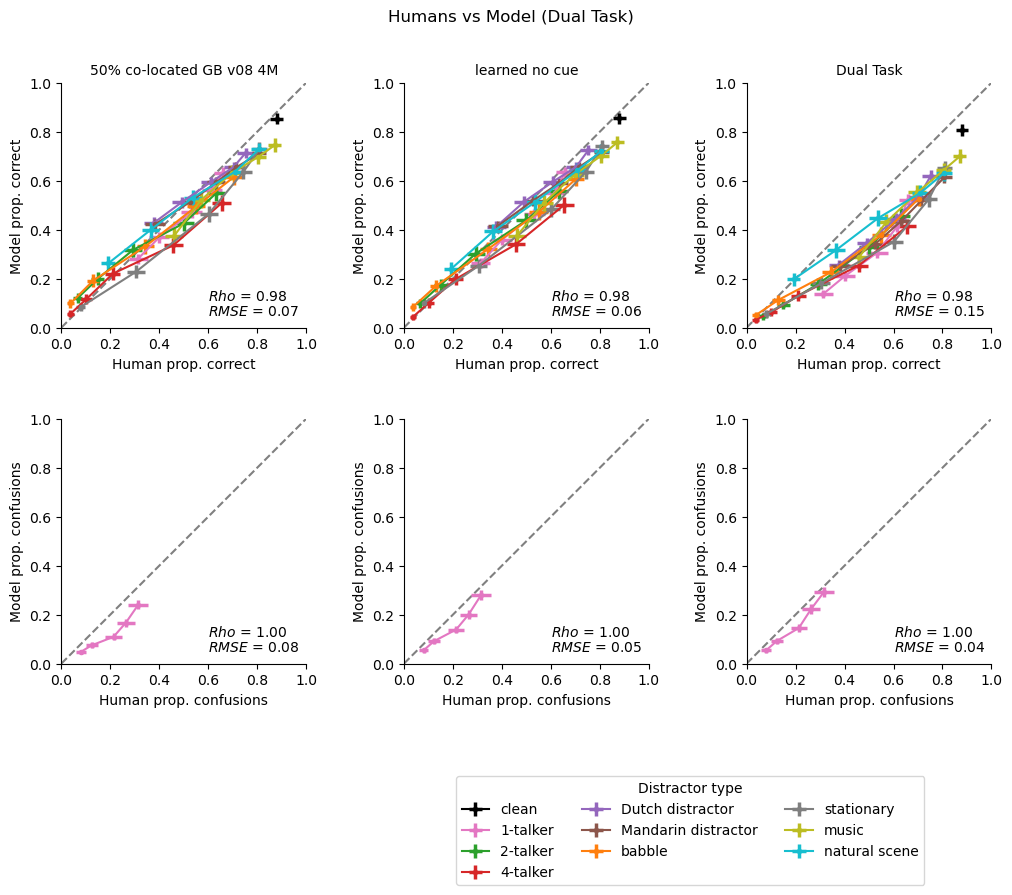

In [28]:
grouped_results = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

# hue_order = summary_df.background_condition.unique()
hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'Dutch distractor', 'Mandarin distractor', 'babble', 'stationary', 'music', 'natural scene',]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))
palette['clean'] = 'k'
palette['1-talker'] = '#e377c2'
palette['babble'] = 'tab:orange'

x = y = np.linspace(0,1,6)


fontsize = 10

# model_list = ["Binaural CommonVoice", "Binaural Half-CoLocated CV", 'Mono CommonVoice', 'Diotic CommonVoice', 'Mono WordSpeakerNoise']
model_list = grouped_results.group.unique()[1:]
n_models = len(model_list)
# fig, axs = plt.subplots(2,len(model_list), figsize=((4*len(model_list)),8))
y_size, x_size = 8, 4
fig, axs = plt.subplots(2,n_models, figsize=((x_size*len(model_list)),y_size))


# for ix, group in enumerate(grouped_results.group.unique()):
# add dashed line to each subplot 
for ax in axs.flat:
    ax.plot(x,y, ls='dashed', color='grey')

human_df = grouped_results[grouped_results.group.str.contains('Participants')]
# get adjusted_confusion data
human_conf_data = human_df[human_df.background_condition ==  "1-talker"]
human_conf_means = human_conf_data["adjusted_confusions"].values
human_conf_errors = human_conf_data["adj_conf_std_error"].values * 2 # 95% CI

for ix, model in enumerate(model_list):
    print(model)
    model_df = grouped_results[grouped_results.group == model]
    # summarize model data
    model_df = model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem'], 
                                                                        'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    

    for condition in hue_order:
        # print(condition)
        # plot acc 
        human_data = human_df[human_df.background_condition == condition]
        human_means = human_data["adjusted_accuracy"].values
        human_errors = human_data["adj_acc_std_error"].values * 2 # 95% CI

        model_data = model_df[model_df.background_condition == condition]
        model_means = model_data["adjusted_accuracy"].values
        model_errors = model_data["adj_acc_std_error"].values * 2 # 95% CI

        axs[0, ix].errorbar(x=human_means, y=model_means, xerr=human_errors, yerr=model_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= condition,
                            color=palette[condition])#, mfc=palette[condition], mec=palette[condition])


    # model adjusted_confusions
    model_conf_data = model_df[model_df.background_condition ==  "1-talker"]
    model_conf_means = model_conf_data["adjusted_confusions"].values
    model_conf_errors = model_conf_data["adj_conf_std_error"].values * 2 # 95% CI 

    axs[1, ix].errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors, yerr=model_conf_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                        color=palette[ "1-talker"])
    
    # Add error annotations 
    # acc errors 
    res = stats.spearmanr(human_df["adjusted_accuracy"].values,  model_df['adjusted_accuracy'].values)
    rho = res.correlation
    axs[0, ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    samp_rmse = np.sqrt(np.mean((human_df["adjusted_accuracy"].values - model_df['adjusted_accuracy'].values)**2))
    axs[0, ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)
    # conf errors
    res = stats.spearmanr(human_conf_means, model_conf_means)
    rho = res.correlation
    axs[1, ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    samp_rmse = np.sqrt(np.mean((human_conf_means - model_conf_means)**2))
    axs[1, ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
    axs[0, ix].set_title(model, fontsize=fontsize)
    axs[0, ix].set_xlabel(f"Human prop. correct", fontsize=fontsize)
    axs[1, ix].set_xlabel(f"Human prop. confusions", fontsize=fontsize)

    axs[0, ix].set_ylabel(f"Model prop. correct", fontsize=fontsize)
    axs[1, ix].set_ylabel(f"Model prop. confusions", fontsize=fontsize)


    
# set first row x and y limits to 0 1 and have same tick values 

# for ax in axs.flat:
#     ax.set_xlim(0,1)
#     ax.set_ylim(0,1)


# make square 
ratio = 1 
for ax in axs.flat:
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_xticks(x)
    ax.set_yticks(y)
    ax.set_aspect(ratio, adjustable='box')
    ax.set_aspect(ratio, adjustable='box')

sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0,0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.4)

fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3, title='Distractor type',  bbox_to_anchor=(0.85, 0),)
# plt.tight_layout()
# 

plt.suptitle(f"Humans vs Model ({model})", y=0.95)



## Compare adjusted to standard scores

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/om2/user/imgriff/conda_envs/torch_

Text(0.5, 0.95, 'in-transcript (y-axis) vs single-word (x-axis) scoring')

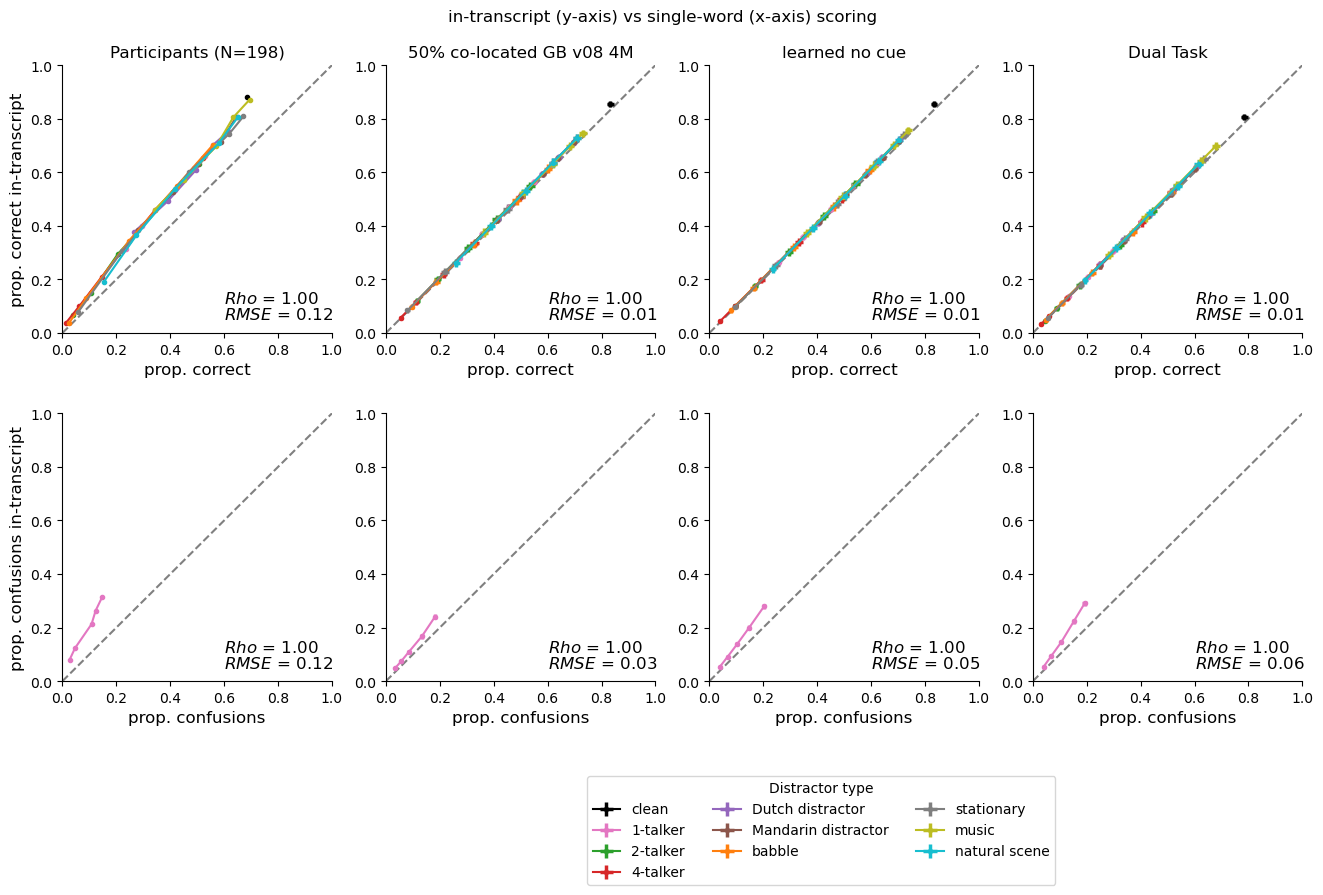

In [30]:
grouped_results = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'Dutch distractor', 'Mandarin distractor', 'babble', 'stationary', 'music', 'natural scene',]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))
palette['clean'] = 'k'
palette['1-talker'] = '#e377c2'
palette['babble'] = 'tab:orange'

x = y = np.linspace(0,1,5)

fontsize = 12
model_list = grouped_results.group.unique()

# model_list = ["Binaural CommonVoice", "Binaural Half-CoLocated CV", 'Mono CommonVoice', 'Diotic CommonVoice', 'Mono WordSpeakerNoise']

n_plots = len(model_list) 
fig, axs = plt.subplots(2,n_plots, figsize=(4*n_plots,8))


# for ix, group in enumerate(grouped_results.group.unique()):
# add dashed line to each subplot 
for ax in axs.flat:
    ax.plot(x,y, ls='dashed', color='grey')

human_df = grouped_results[grouped_results.group == f'Participants (N={N})']
# get adjusted_confusion data
human_conf_data = human_df[human_df.background_condition ==  "1-talker"]
human_conf_means = human_conf_data["adjusted_confusions"].values
human_conf_errors = human_conf_data["adj_conf_std_error"].values

for ix in range(n_plots):
    # if ix == 0:
        # plot_df = grouped_results[grouped_results.group == f'participants (N={N})']
    # else:
    model = model_list[ix]
    plot_df = grouped_results[grouped_results.group == model]
    # summarize model data
    plot_df = plot_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem'], 
                                                                        'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    plot_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']

    for condition in hue_order:
        # plot acc 
        data = plot_df[plot_df.background_condition == condition]
        means = data["accuracy"].values
        errors = data["acc_std_error"].values
        adj_means = data["adjusted_accuracy"].values
        adj_errors = data["adj_acc_std_error"].values

        axs[0,ix].errorbar(x=means, y=adj_means, xerr=errors, yerr=adj_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= condition,
                            color=palette[condition])#, mfc=palette[condition], mec=palette[condition])


    # model adjusted_confusions
    conf_data = plot_df[plot_df.background_condition ==  "1-talker"]
    conf_means = conf_data["confusions"].values
    conf_errors = conf_data["conf_std_error"].values
    adj_conf_means = conf_data["adjusted_confusions"].values
    adj_conf_errors = conf_data["adj_conf_std_error"].values

    axs[1,ix].errorbar(x=conf_means, y=adj_conf_means, xerr=conf_errors, yerr=adj_conf_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                        color=palette[ "1-talker"])
    
    # Add error annotations 
    # acc errors 
    res = stats.spearmanr(plot_df["accuracy"].values,  plot_df['adjusted_accuracy'].values)
    rho = res.correlation
    axs[0,ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    samp_rmse = np.sqrt(np.mean((plot_df["accuracy"].values - plot_df['adjusted_accuracy'].values)**2))
    axs[0,ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)
    # conf errors
    res = stats.spearmanr(conf_means, adj_conf_means)
    rho = res.correlation
    axs[1,ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    samp_rmse = np.sqrt(np.mean((conf_means - adj_conf_means)**2))
    axs[1,ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
    axs[0,ix].set_title(model, fontsize=fontsize)
    axs[0,ix].set_xlabel(f"prop. correct", fontsize=fontsize)
    axs[1,ix].set_xlabel(f"prop. confusions", fontsize=fontsize)

    
# set first row x and y limits to 0 1
for ax in axs.flat:
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

axs[0,0].set_ylabel(f"prop. correct in-transcript", fontsize=fontsize)
axs[1,0].set_ylabel(f"prop. confusions in-transcript", fontsize=fontsize)

sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0,0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(hspace=0.3)

fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3, title='Distractor type',  bbox_to_anchor=(0.75, 0),)
# plt.tight_layout()



plt.suptitle(f"in-transcript (y-axis) vs single-word (x-axis) scoring", y=0.95)



## Look at same vs different distractor sex  and distractor language 

In [31]:
# # combine f0_analysis_df and model_f0_df keeping only columns in both
# model_f0_df['id_subject'] = 'model'
# model_f0_df['group'] = 'model'
all_model_f0_results['id_subject'] = all_model_f0_results['group']
f0_analysis_df['group'] = 'participants'
f0_analysis_df.loc[f0_analysis_df.snr == 'inf', 'sex_cond'] = 'Clean'
f0_analysis_df.loc[f0_analysis_df.snr == 'inf', 'dist_lang'] = 'None'
all_model_f0_results.loc[all_model_f0_results.snr == 'inf', 'sex_cond'] = 'Clean'

f0_analysis_df.reset_index(inplace=True, drop=True)


human_dist_df = (f0_analysis_df.groupby(["snr", "id_subject", "sex_cond", "dist_lang"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

human_dist_df['snr'] = human_dist_df['snr'].replace(np.inf, 6)
human_dist_df['snr'] =  human_dist_df['snr'].replace("inf", 6)
human_dist_df['snr'] = human_dist_df['snr'].astype('int')
# flatten multiindex 
human_dist_df.columns = ['_'.join(col).strip() for col in human_dist_df.columns.values]
# remove trailing underscore
human_dist_df.columns = [col[:-1] if col.endswith('_') else col for col in human_dist_df.columns.values]

# human summary

### Human distractor sex summary 
summary_sex_cond_df = human_dist_df.groupby(['snr', 'sex_cond']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
summary_sex_cond_df.columns = ['snr', 'sex_cond', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']

### Human distractor language summary 
summary_dist_lang_df = human_dist_df.groupby(['snr', 'dist_lang']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
summary_dist_lang_df.columns = ['snr', 'dist_lang', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']

### combine with model 
## distractor sex 
N = int(f0_analysis_df.id_subject.nunique())
summary_sex_cond_df['group'] = f'Participants (N={N})'
combined_dist_sex_results = pd.concat([summary_sex_cond_df, all_model_f0_results], axis=0, ignore_index=True)
combined_dist_sex_results.loc[combined_dist_sex_results.snr == np.inf, 'snr'] = 6
combined_dist_sex_results.loc[combined_dist_sex_results.snr == 'inf', 'snr'] = 6
combined_dist_sex_results.snr = combined_dist_sex_results.snr.astype('int')

## distractor language 
summary_dist_lang_df['group'] = f'Participants (N={N})'
combined_dist_lang_results = pd.concat([summary_dist_lang_df, all_model_f0_results], axis=0, ignore_index=True)
combined_dist_lang_results.loc[combined_dist_lang_results.snr == np.inf, 'snr'] = 6
combined_dist_lang_results.loc[combined_dist_lang_results.snr == 'inf', 'snr'] = 6
combined_dist_lang_results.snr = combined_dist_lang_results.snr.astype('int')


In [32]:
# combined_dist_sex_results

### Plot same vs different sex 

Participants (N=198)
Clean
Different
Same


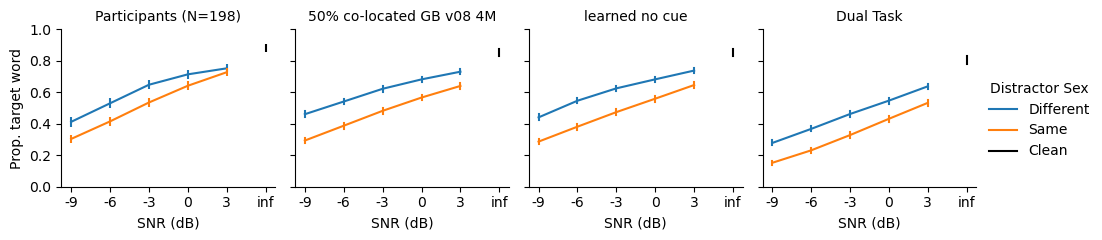

In [33]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_dist_sex_results.copy()

# hue_order = summary_df.background_condition.unique()
hue_order = ['Different', 'Same', 'Clean']

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))
palette['Clean'] = 'k'
# palette['1-talker'] = '#e377c2'
# palette['babble'] = 'tab:orange'
# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='adjusted_accuracy', col='group',
                 hue='sex_cond', hue_order=hue_order, #col_wrap=4,
                  kind='line', marker='',
                  palette=palette,
                  height=2.5, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Prop. target word")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    if model != f"Participants (N={N})":
        continue 
    # select the data for the facet
    print(model)
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('sex_cond'):
        print(group)
        # plot the errorbar with the correct color for each group 
        selected['adj_acc_std_error'] = selected['adj_acc_std_error'] * 2

        ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)
g._legend.set_title('Distractor Sex')
# plt.suptitle(f"Using in-transcript accuracy", y=1.05)
# plt.tight_layout()

Participants (N=198)
Different
Same


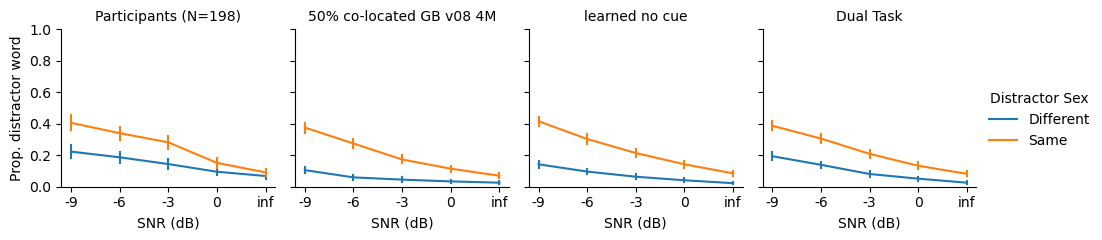

In [34]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]

# human summary
### Human distractor sex summary 
to_plot = human_dist_df[human_dist_df.dist_lang == 'English']
N = int(to_plot.id_subject.nunique())
to_plot = to_plot.groupby(['snr', 'sex_cond']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
to_plot.columns = ['snr', 'sex_cond', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']

## distractor sex 
to_plot['group'] = f'Participants (N={N})'
combined_dist_sex_results = pd.concat([to_plot, all_model_f0_results[all_model_f0_results.dist_lang == 'English']], axis=0, ignore_index=True)
combined_dist_sex_results.loc[combined_dist_sex_results.snr == np.inf, 'snr'] = 6
combined_dist_sex_results.loc[combined_dist_sex_results.snr == 'inf', 'snr'] = 6
combined_dist_sex_results.snr = combined_dist_sex_results.snr.astype('int')


# hue_order = summary_df.background_condition.unique()
hue_order = ['Different', 'Same']

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))
palette['Clean'] = 'k'
# palette['1-talker'] = '#e377c2'
# palette['babble'] = 'tab:orange'
# add markers to relplot
g = sns.relplot(data=combined_dist_sex_results, x='snr', y='adjusted_confusions', col='group',
                 hue='sex_cond', hue_order=hue_order, #col_wrap=4,
                  kind='line', marker='',
                  palette=palette,
                  height=2.5, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "confusions", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Prop. distractor word")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    if model != f"Participants (N={N})":
        continue 
    # select the data for the facet
    print(model)
    data = combined_dist_sex_results[combined_dist_sex_results['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('sex_cond'):
        print(group)
        # plot the errorbar with the correct color for each group 
        selected['adj_conf_std_error'] = selected['adj_conf_std_error'] * 2

        ax.errorbar(data=selected, x="snr", y="adjusted_confusions", yerr="adj_conf_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = combined_dist_sex_results.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)
g._legend.set_title('Distractor Sex')
# plt.suptitle(f"Using in-transcript confusions", y=1.05)
# plt.tight_layout()

### Plot single English talker results 

/tmp/ipykernel_673740/1476159334.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected['adj_acc_std_error'] = selected['adj_acc_std_error'] * 2
/tmp/ipykernel_673740/1476159334.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected['adj_conf_std_error'] = selected['adj_conf_std_error'] * 2


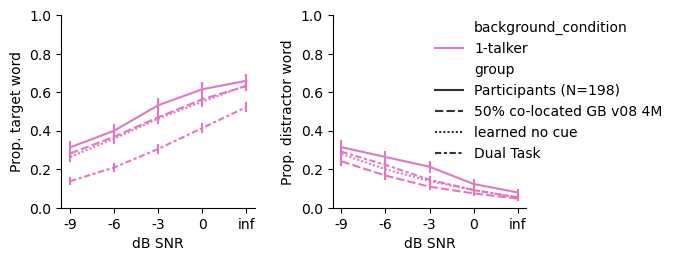

In [35]:
fig, axs = plt.subplots(1,2, figsize=(6,2.5))

# human summary
### Human distractor sex summary 
human_to_plot = human_dist_df[human_dist_df.dist_lang == 'English']
N = int(human_to_plot.id_subject.nunique())
human_to_plot = human_to_plot.groupby(['snr']).agg({'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
human_to_plot.columns = ['snr', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']
human_to_plot['background_condition'] = '1-talker'
## distractor sex 
human_to_plot['group'] = f'Participants (N={N})'
to_plot = pd.concat([human_to_plot, all_model_f0_results[all_model_f0_results.dist_lang == 'English']], axis=0, ignore_index=True)
to_plot.loc[to_plot.snr == np.inf, 'snr'] = 6
to_plot.loc[to_plot.snr == 'inf', 'snr'] = 6
to_plot.snr = to_plot.snr.astype('int')

palette = {}
palette["1-talker"] = '#e377c2'
# to_plot = to_plot.drop(columns=['target_transcript', 'distractor_transcript'])
# to_plot.drop_duplicates(inplace=True)

style_order = to_plot.group.unique()

# style_order = ['participants (N=81)', 'Diotic CommonVoice', 'Mono CommonVoice', 'Mono WordSpeakerNoise', 'Binaural CommonVoice', "Binaural Half-CoLocated CV"]


g1 = sns.lineplot(data=to_plot, x = 'snr', y = 'adjusted_accuracy',  err_style='bars', errorbar=('ci', 95),
                   style='group',style_order=style_order, 
                   hue='background_condition', palette=palette,
            ax=axs[0])

g2 = sns.lineplot(data=to_plot, x = 'snr', y = 'adjusted_confusions',  err_style='bars', errorbar=('ci', 95),
                   style='group',style_order=style_order, 
                   hue='background_condition', palette=palette,
            ax=axs[1])

# add error bars for participants
# iterate through each facet of the facetgrid
# select the data for each hue group
selected = to_plot[(to_plot['group'].eq(f'Participants (N={N})')) & (to_plot['background_condition'].eq('1-talker'))]
selected['adj_acc_std_error'] = selected['adj_acc_std_error'] * 2
selected['adj_conf_std_error'] = selected['adj_conf_std_error'] * 2
g1.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette["1-talker"], marker=None, ls='none' )
g2.errorbar(data=selected, x="snr", y="adjusted_confusions", yerr="adj_conf_std_error", color=palette["1-talker"], marker=None, ls='none' )


g1.set_xticks(ticks=x_tick_locs) # set new labels
g2.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticklabels(labels=x_tick_labels)
g2.set_xticklabels(labels=x_tick_labels)
g1.set_ylim(0,1)
g2.set_ylim(0,1)

g1.legend().remove()     
# g2.legend().remove()

# add space between plots
plt.subplots_adjust(wspace=0.4)
sns.despine()

# remove legend titles 
g2.legend_.set_title('')
axs[0].set_xlabel("dB SNR")
axs[1].set_xlabel("dB SNR")

axs[0].set_ylabel("Prop. target word")
axs[1].set_ylabel("Prop. distractor word")

# remove last element from legend 
handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(handles[:-1], labels[:-1], frameon=False, bbox_to_anchor=(0.5, 1), loc=2, borderaxespad=0., title='')

### Plot unfamiliar distractor

In [36]:
selected

,snr,adjusted_accuracy,adj_acc_std_error,adjusted_confusions,adj_conf_std_error,background_condition,group,pred_word_int,true_word_int,accuracy,...,pred_word,true_word,confusions,sex_cond,dist_lang,distractor_f0,abs_f0_diff,percent_f0_diff,f0_ratio,id_subject
0,-9,0.313552,0.035312,0.314394,0.037044,1-talker,Participants (N=198),NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-6,0.400253,0.037210,0.263468,0.033399,1-talker,Participants (N=198),NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-3,0.532407,0.038402,0.212963,0.030615,1-talker,Participants (N=198),NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0.615530,0.036776,0.123316,0.023360,1-talker,Participants (N=198),NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3,0.659512,0.034113,0.079545,0.019086,1-talker,Participants (N=198),NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
combined_dist_lang_results.dist_lang.unique()

array(['Dutch', 'English', 'Mandarin', 'None', nan], dtype=object)

Participants (N=198)
Dutch
English
Mandarin
No distractor


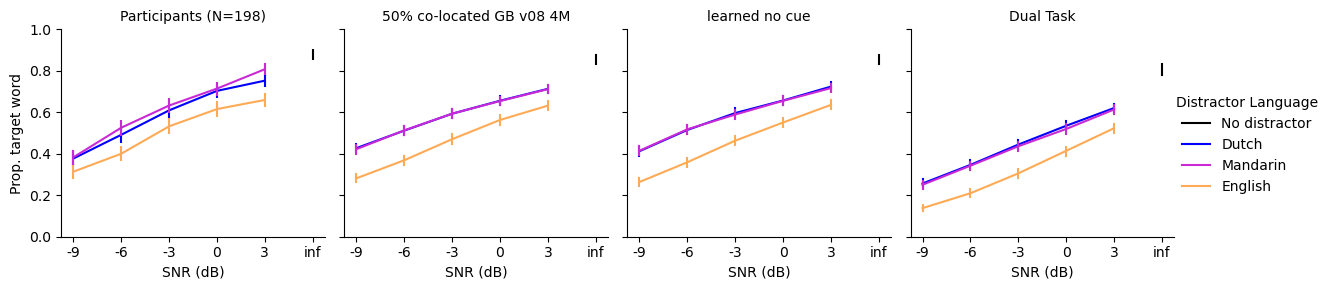

In [38]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_dist_lang_results.copy()

to_plot.loc[to_plot.dist_lang == 'None', "dist_lang"] = 'No distractor'
to_plot.loc[to_plot.dist_lang.isna(), "dist_lang"] = 'No distractor'

# hue_order = summary_df.background_condition.unique()
cmap = sns.color_palette("gnuplot2", n_colors=3)

hue_order = ['No distractor', 'Dutch', 'Mandarin', 'English']

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

palette = {lang:cmap[ix] for ix, lang in enumerate(hue_order[1:])}
palette['No distractor'] = 'k'


# palette['1-talker'] = '#e377c2'
# palette['babble'] = 'tab:orange'
# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='adjusted_accuracy', col='group',
                 hue='dist_lang', hue_order=hue_order, #col_wrap=4,
                  kind='line', marker='',
                  palette=palette,
                  height=3, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Prop. target word")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    if model != f"Participants (N={N})":
        continue 
    # select the data for the facet
    print(model)
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('dist_lang'):
        print(group)
        # plot the errorbar with the correct color for each group 
        selected['adj_acc_std_error'] = selected['adj_acc_std_error'] * 2

        ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)
g._legend.set_title('Distractor Language')
# plt.suptitle(f"Using in-transcript accuracy", y=1.05)
# plt.tight_layout()

## F0 

In [39]:
# # combine f0_analysis_df and model_f0_df keeping only columns in both
# model_f0_df['id_subject'] = 'model'
# model_f0_df['group'] = 'model'
all_model_f0_results['id_subject'] = all_model_f0_results['group']
f0_analysis_df['group'] = 'participants'

f0_analysis_df.reset_index(inplace=True, drop=True)
all_model_f0_results.reset_index(inplace=True, drop=True)
combined_f0_df = pd.concat([f0_analysis_df, all_model_f0_results],axis=0, ignore_index=True)

# combined_f0_df = combined_f0_df[combined_f0_df.background_condition == '1-talker']
combined_f0_df.loc[combined_f0_df.snr == "inf", 'snr'] = 6
combined_f0_df.snr = combined_f0_df.snr.astype('int')

# combined_f0_df = combined_f0_df[combined_f0_df.abs_f0_diff < 125]

In [40]:
combined_f0_df.target_f0.max(), combined_f0_df.distractor_f0.max()

(278.8183898925781, 290.5749206542969)

In [41]:
# drop rows with nan target f0
combined_f0_df.dropna(subset=['snr','abs_f0_diff'], inplace=True)


In [42]:
combined_f0_df['correct_str'] = combined_f0_df['accuracy'].replace({0: "Miss", 1:"Hit"})

In [43]:
# combined_f0_df['abs_f0_diff'] = combined_f0_df['abs_f0_diff'].astype('float')
# combined_f0_df['percent_f0_diff'] = (combined_f0_df.distractor_f0.values / combined_f0_df.target_f0.values).astype('float')


participants
50% co-located GB v08 4M
learned no cue
Dual Task


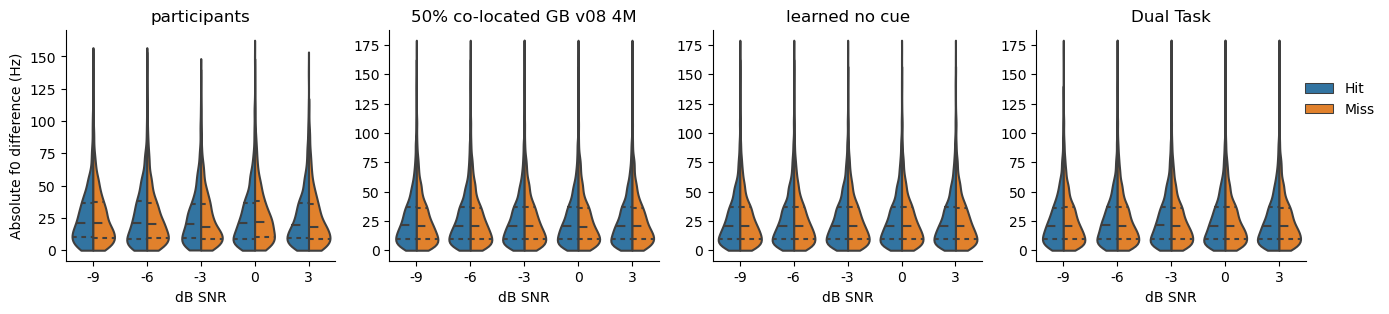

In [44]:
# g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
n_models = combined_f0_df.group.nunique()
fig, axes = plt.subplots(1,combined_f0_df.group.nunique(),figsize=(4 * n_models,3))

# need to fix, for now, toss bad examples 
# combined_f0_df.loc[combined_f0_df.abs_f0_diff > 200, 'abs_f0_diff'] = np.nan

fontsize=10
for ix, group_name in enumerate(combined_f0_df.group.unique()):
    print(group_name)
    ax = sns.violinplot(data=combined_f0_df[combined_f0_df.group == group_name], x="snr", y="abs_f0_diff", cut=0, 
                        hue="correct_str", split=True, gap=.5, inner="quart", ax=axes[ix])

    ax.set_title(group_name)
    if ix < n_models - 1:
        ax.get_legend().remove()
    if ix == 0:
        ax.set_ylabel('Absolute f0 difference (Hz)', fontsize=fontsize)
    elif ix > 0:
        ax.set_ylabel('')
    ax.set_xlabel('dB SNR', fontsize=fontsize)


# if ix == 2:
sns.move_legend(ax, title='',
                loc="center right", bbox_to_anchor=(1.3, .7),
                frameon=False, title_size=fontsize, fontsize=fontsize)
sns.despine()
# ax1.set_ylabel('% f0 difference', fontsize=fontsize)


In [45]:
# pd.cut(to_plot['abs_f0_diff'], bins=5, labels=[0, 25, 50, 100, 150])

In [46]:
f0_analysis_df.columns

Index(['time_elapsed', 'internal_node_id', 'output_filename', 'id_random',
       'id_study', 'id_subject', 'id_session', 'id_version', 'hc_passed', 'rt',
       'response', 'stimulus', 'over_ear_hf', 'hearing_loss', 'response_str',
       'correct_response', 'correct', 'n_correct', 'n_incorrect', 'snr',
       'raw_condition', 'background_condition', 'accuracy', 'stim_name',
       'gender', 'word', 'target_f0', 'english_distractor_f0',
       'mandarin_distractor_f0', 'dutch_distractor_f0', 'target_transcripts',
       'same_sex_distractor_1_transcripts',
       'diff_sex_distractor_1_transcripts', 'same_sex_dist_1_word',
       'diff_sex_dist_1_word', 'confusions', 'adjusted_accuracy',
       'adjusted_confusions', 'sex_cond', 'dist_lang', 'distractor_f0',
       'abs_f0_diff', 'percent_f0_diff', 'f0_ratio', 'group'],
      dtype='object')

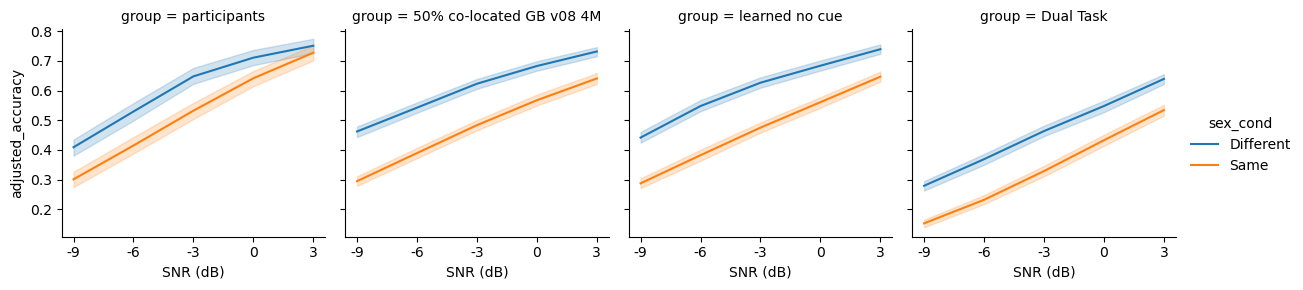

In [47]:
## For f0 plots 
to_plot = combined_f0_df[combined_f0_df.snr.isin(np.arange(-9,6))]

g = sns.relplot(data=to_plot, x='snr', y='adjusted_accuracy', hue='sex_cond', kind='line',
                     col='group', height=3, aspect=1)
x_tick_locs = sorted(to_plot.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]

for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
g.set_xlabels("SNR (dB)")

In [48]:
to_plot.dist_lang.unique()

array(['Mandarin', 'Dutch', 'English'], dtype=object)

[7.80487061e-03 4.47676830e+01 8.95275612e+01 1.34287439e+02
 1.79047318e+02]


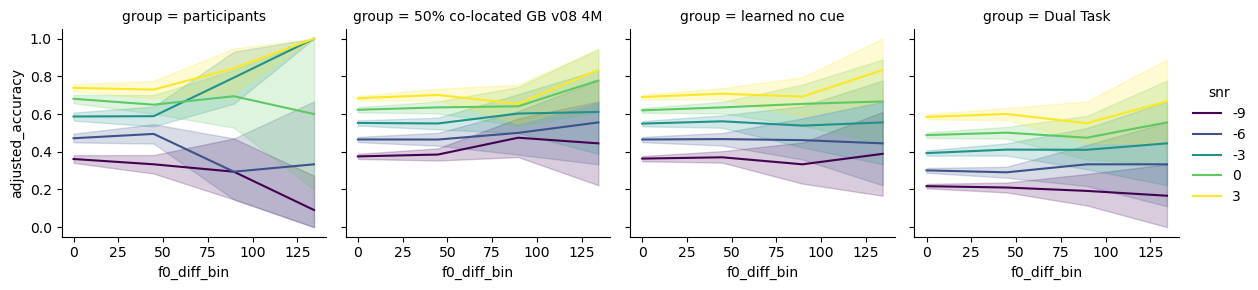

In [49]:
## For f0 plots 
n_models = combined_f0_df.group.nunique()
to_plot = combined_f0_df[combined_f0_df.snr.isin(np.arange(-9,6))]
# to_plot = 
# histogram abs_f0_diff into 5 bins 
n_bins = 5

min_f0_diff = to_plot.abs_f0_diff.min()
max_f0_diff = to_plot.abs_f0_diff.max()
bins = np.linspace(min_f0_diff, max_f0_diff, n_bins)
print(bins)
to_plot['f0_diff_bin'] = pd.cut(to_plot['abs_f0_diff'], bins=bins, labels=bins[:-1])
# to_plot = to_plot.groupby(['id_subject',  'group', 'snr', 'f0_diff_bin']).agg({'adjusted_accuracy':np.nanmean, 'adjusted_confusions':np.nanmean}).reset_index()

to_plot
sns.relplot(data=to_plot, x='f0_diff_bin', y='adjusted_accuracy', col='group', hue='snr', kind='line', palette='viridis', height=3, aspect=1)


[7.80487061e-03 2.98477236e+01 5.96876424e+01 8.95275612e+01
 1.19367480e+02 1.49207399e+02 1.79047318e+02]


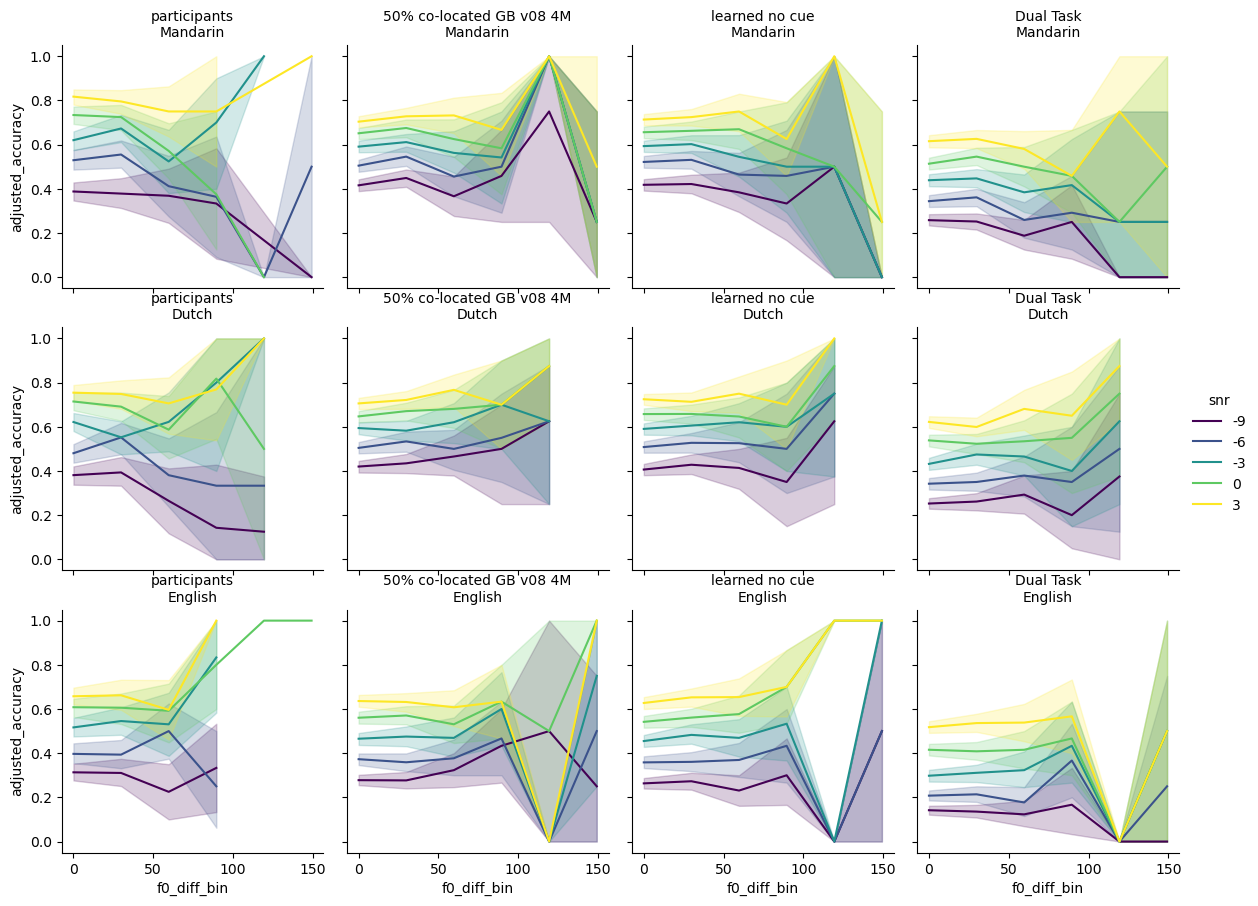

In [50]:
## For f0 plots 
n_models = combined_f0_df.group.nunique()
to_plot = combined_f0_df[combined_f0_df.snr.isin(np.arange(-9,6))]
# to_plot = 
# histogram abs_f0_diff into 5 bins 
n_bins = 7

min_f0_diff = to_plot.abs_f0_diff.min()
max_f0_diff = to_plot.abs_f0_diff.max()
bins = np.linspace(min_f0_diff, max_f0_diff, n_bins)
print(bins)
to_plot['f0_diff_bin'] = pd.cut(to_plot['abs_f0_diff'], bins=bins, labels=bins[:-1])
# to_plot = to_plot.groupby(['id_subject',  'group', 'snr', 'f0_diff_bin']).agg({'adjusted_accuracy':np.nanmean, 'adjusted_confusions':np.nanmean}).reset_index()

to_plot
g = sns.relplot(data=to_plot, x='f0_diff_bin', y='adjusted_accuracy', col='group', row='dist_lang', hue='snr', kind='line', palette='viridis', height=3, aspect=1)
# set titles 
g.set_titles("{col_name}\n{row_name}")

In [51]:
# plot accuracy vs f0 difference with lines as snr and columns for group
n_models = combined_f0_df.group.nunique()
to_plot = combined_f0_df[combined_f0_df.snr.isin(np.arange(-9,4,3))]
# histogram abs_f0_diff into 5 bins 
n_bins = 10
min_f0_diff = combined_f0_df[combined_f0_df.abs_f0_diff > 10].abs_f0_diff.min()
max_f0_diff = combined_f0_df.abs_f0_diff.max()
bins = np.linspace(min_f0_diff, max_f0_diff, n_bins)
print(bins)
to_plot['abs_f0_diff_bin'] = pd.cut(to_plot['abs_f0_diff'], bins=n_bins, labels=bins)



[ 10.00749207  28.78969489  47.57189772  66.35410055  85.13630337
 103.9185062  122.70070903 141.48291185 160.26511468 179.0473175 ]


participants
50% co-located GB v08 4M
learned no cue
Dual Task


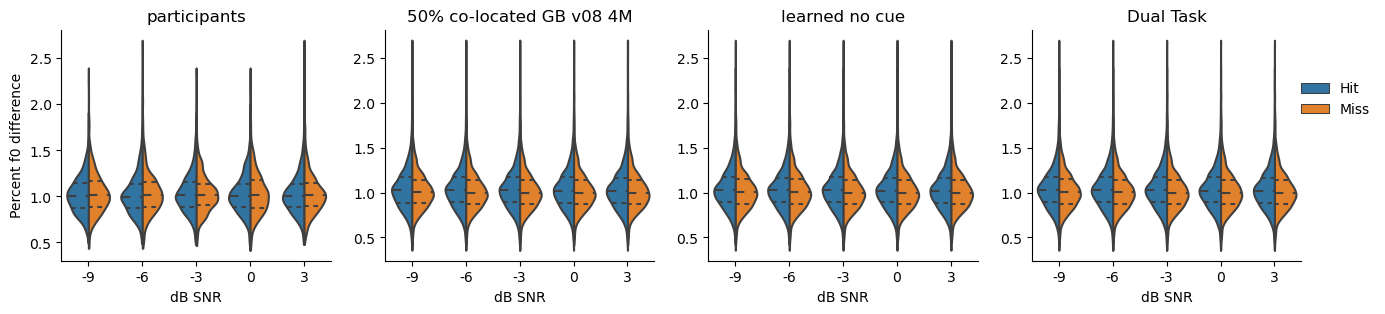

In [52]:
# g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
n_models = combined_f0_df.group.nunique()
fig, axes = plt.subplots(1,combined_f0_df.group.nunique(),figsize=(4 * n_models,3))

fontsize=10
for ix, group_name in enumerate(combined_f0_df.group.unique()):
    print(group_name)
    ax = sns.violinplot(data=combined_f0_df[combined_f0_df.group == group_name], x="snr", y="percent_f0_diff", cut=0, 
                        hue="correct_str", split=True, gap=.5, inner="quart", ax=axes[ix])

    ax.set_title(group_name)
    if ix < n_models - 1:
        ax.get_legend().remove()
    if ix == 0:
        ax.set_ylabel('Percent f0 difference', fontsize=fontsize)
    elif ix > 0:
        ax.set_ylabel('')
    ax.set_xlabel('dB SNR', fontsize=fontsize)


# if ix == 2:
sns.move_legend(ax, title='',
                loc="center right", bbox_to_anchor=(1.3, .7),
                frameon=False, title_size=fontsize, fontsize=fontsize)
sns.despine()
# ax1.set_ylabel('% f0 difference', fontsize=fontsize)


In [53]:
combined_f0_df.group.unique()

array(['participants', '50% co-located GB v08 4M', 'learned no cue',
       'Dual Task'], dtype=object)

[0.5        0.62996052 0.79370053 1.         1.25992105 1.58740105
 2.        ]


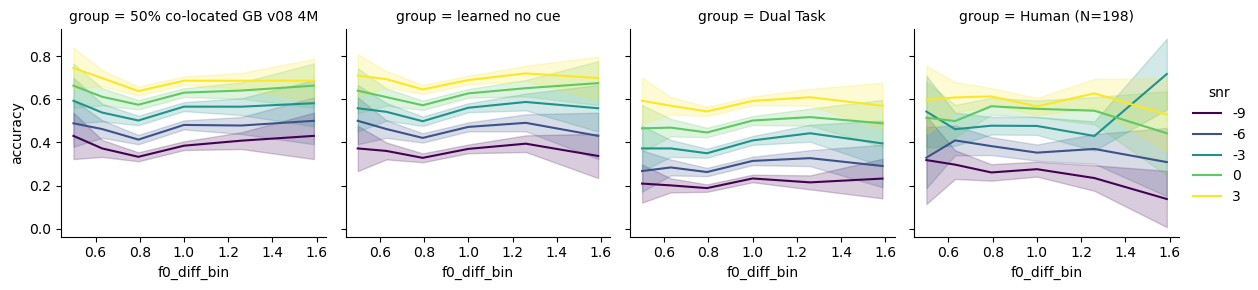

In [54]:
## Same but with percent f0 difference

## For f0 plots 
n_models = combined_f0_df.group.nunique()
to_plot = combined_f0_df[combined_f0_df.snr.isin(np.arange(-9,6))].copy()
# histogram percent_f0_diff into 5 bins 
n_bins = 7

# min_f0_diff = to_plot[(to_plot.percent_f0_diff > 5) & (to_plot.group == 'participants')].percent_f0_diff.min()
# max_f0_diff = to_plot[(to_plot.group == 'participants')].percent_f0_diff.max()
bins = np.geomspace(0.5, 2, n_bins)
# bins=[0,5,10,25,50,100]
print(bins)
to_plot['f0_diff_bin'] = pd.cut(to_plot['percent_f0_diff'], bins=bins, labels=bins[:-1], right=False)
# to_plot['f0_diff_bin'] = pd.qcut(to_plot['percent_f0_diff'], q=5, labels=['large low', 'small low', 'same', 'small up', 'large up'])

to_plot_model = to_plot[to_plot.group != f'participants']
to_plot_human = to_plot[to_plot.group == f'participants']

to_plot_human = to_plot_human.groupby(['id_subject', 'snr', 'f0_diff_bin']).agg({'accuracy':np.nanmean, 'confusions':np.nanmean}).reset_index()
to_plot_human['group'] = f'Human (N={N})'

to_plot = pd.concat([to_plot_model, to_plot_human], axis=0, ignore_index=True)
sns.relplot(data=to_plot, x='f0_diff_bin', y='accuracy', col='group',
            errorbar=('se', 2),
            hue='snr', kind='line', palette='viridis', height=3, aspect=1)


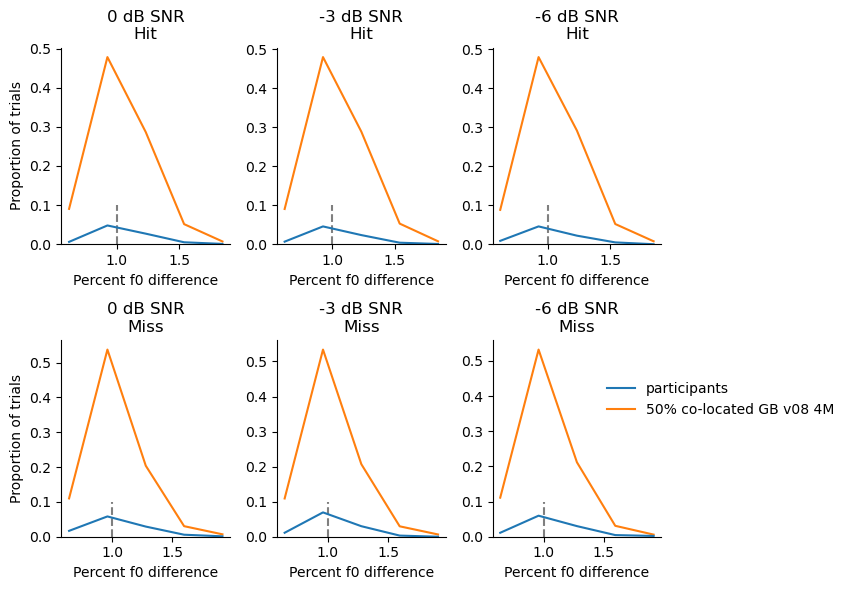

In [ ]:
# g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
n_models = combined_f0_df.group.nunique()
snrs = sorted(combined_f0_df.snr.unique())[1:-1]

fig, axes = plt.subplots(2, len(snrs), figsize=( 3 * len(snrs), 6))

# set colors
# palette = {'Hit':'tab:blue', 'Miss':'tab:orange'} 

fontsize=10
for ix, cond_name in enumerate(['Hit', 'Miss']):
    for jx, snr_val in enumerate(snrs[::-1]):
        ## Add v line at 1 
        axes[ix,jx].vlines(1,0, 0.1, colors='k', linestyle='dashed', alpha=0.5)
        ax = sns.histplot(data=combined_f0_df[(combined_f0_df.correct_str == cond_name) & (combined_f0_df.snr == snr_val)],
                        x="percent_f0_diff", 
                        stat='proportion',
                        bins=5,
                        shrink=.8,
                        element="poly",
                        fill=False,
                        hue="group",
                        ax=axes[ix, jx])

        ax.set_title(f"{snr_val} dB SNR\n{cond_name}")
        if jx < len(snrs) - 1 or ix == 0:
            ax.get_legend().remove()
        if jx == 0:
            ax.set_ylabel('Proportion of trials', fontsize=fontsize)
        elif jx > 0:
            ax.set_ylabel('')
        ax.set_xlabel('Percent f0 difference', fontsize=fontsize)
#         ax.set_ylim(0,0.1)
        # set xticks 
        # ax.set_xticks(np.linspace(0.5,2.5,5))
        # ax.set_xlim(0.4,2.6)

# if ix == 2:
sns.move_legend(ax, title='',
                loc="center right", bbox_to_anchor=(2.1, .7),
                frameon=False, title_size=fontsize, fontsize=fontsize)
sns.despine()
plt.tight_layout()
# ax1.set_ylabel('% f0 difference', fontsize=fontsize)


In [ ]:
n_models, snrs


(2, [-6, -3, 0])

In [ ]:
snrs[::-1]

[0, -3, -6]

In [ ]:
# # g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# # sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
# n_models = combined_f0_df.group.nunique()
# snrs = combined_f0_df.snr.unique()
# snrs.sort()
# fig, axes = plt.subplots(len(snrs), n_models, figsize=(4 * len(snrs), 3 * n_models))

# # set colors
# palette = {'Hit':'tab:blue', 'Miss':'tab:orange'} 

# fontsize=10
# for ix, group_name in enumerate(combined_f0_df.group.unique()):
#     print(group_name)
#     for jx, snr_val in enumerate(snrs[::-1]):
#         ax = sns.histplot(data=combined_f0_df[(combined_f0_df.group == group_name) & (combined_f0_df.snr == snr_val)],
#                         x="percent_f0_diff", 
#                         stat='proportion',
#                         palette=palette,
#                         multiple="dodge", shrink=.8,
#                         hue="correct_str", ax=axes[jx, ix])

#         ax.set_title(f"{snr_val} dB SNR\n{group_name}")
#         if ix < n_models - 1:
#             ax.get_legend().remove()
#         if ix == 0:
#             ax.set_ylabel('Proportion of trials', fontsize=fontsize)
#         elif ix > 0:
#             ax.set_ylabel('')
#     ax.set_xlabel('Percent f0 difference', fontsize=fontsize)


# # if ix == 2:
# sns.move_legend(ax, title='',
#                 loc="center right", bbox_to_anchor=(1.3, .7),
#                 frameon=False, title_size=fontsize, fontsize=fontsize)
# sns.despine()
# plt.tight_layout()
# # ax1.set_ylabel('% f0 difference', fontsize=fontsize)


### Look at f0 ratio

In [ ]:
def get_f0_ratio(target_f0, distractor_f0):
    return max(target_f0, distractor_f0) / min(target_f0, distractor_f0)

combined_f0_df['f0_ratio'] = combined_f0_df.apply(lambda x: get_f0_ratio(x.target_f0, x.distractor_f0), axis=1)

In [ ]:
combined_f0_df.group

0                    participants
2                    participants
3                    participants
4                    participants
5                    participants
                   ...           
32594    50% co-located GB v08 4M
32595    50% co-located GB v08 4M
32596    50% co-located GB v08 4M
32597    50% co-located GB v08 4M
32598    50% co-located GB v08 4M
Name: group, Length: 32133, dtype: object

[1.   1.25 1.5  1.75 2.   2.25]


/tmp/ipykernel_2839999/1859459004.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot_model['group'] = 'Model'


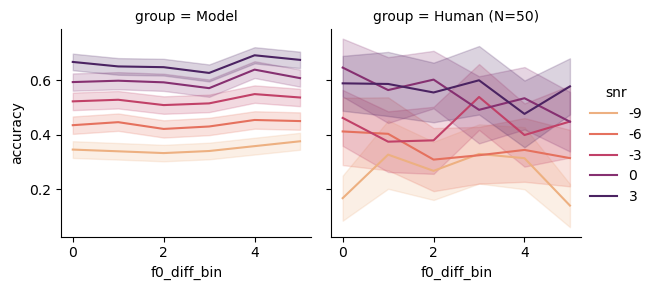

In [ ]:
## Same but with percent f0 difference

## For f0 plots 
n_models = combined_f0_df.group.nunique()
to_plot = combined_f0_df[combined_f0_df.snr.isin(np.arange(-9,6))].copy()
# histogram percent_f0_diff into 5 bins 
n_bins = 6

bins = np.linspace(1, 2.25, n_bins)
# bins=[0,5,10,25,50,100]
print(bins)
# to_plot['f0_diff_bin'] = pd.cut(to_plot['f0_ratio'], bins=bins, labels=bins[:-1], right=False)
to_plot['f0_diff_bin'] = pd.qcut(to_plot['f0_ratio'],q=n_bins, labels=np.arange(n_bins))

to_plot_model = to_plot[to_plot.group != f'participants']
to_plot_human = to_plot[to_plot.group == f'participants']


to_plot_model['group'] = 'Model'

to_plot_human = to_plot_human.groupby(['id_subject', 'snr', 'f0_diff_bin']).agg({'accuracy':np.nanmean, 'confusions':np.nanmean}).reset_index()
to_plot_human['group'] = f'Human (N={N})'

to_plot = pd.concat([to_plot_model, to_plot_human], axis=0, ignore_index=True)

sns.relplot(data=to_plot, x='f0_diff_bin', y='accuracy', col='group',
            errorbar=('se', 2),
            hue='snr', kind='line',
            palette='flare', height=3, aspect=1)


In [ ]:
# get trial data excluding catch trials 
# f0_analysis_df

sex_cond_df = (combined_f0_df.groupby(["background_condition", "snr", 'id_subject', "sex_cond", 'gender'])
                     .agg({"accuracy":"mean", 'confusions':'mean', "adjusted_accuracy":"mean", "adjusted_confusions": "mean"})
                     .reset_index())

# human_f0_close['group'] = 'participants'

# flatten multi index


# human_f0_close['group'] = 'participants'
# model_list  = grouped_results.group.unique()
model_list = combined_f0_df.group.unique()[1:]


sex_cond_df.loc[~sex_cond_df.id_subject.isin(model_list), 'group'] = 'Participants'
for model in model_list:
    sex_cond_df.loc[sex_cond_df.id_subject == model, 'group'] = model

sex_cond_df.loc[sex_cond_df.snr == np.inf, 'snr'] = 6
sex_cond_df.loc[sex_cond_df.snr == "inf", 'snr'] = 6
sex_cond_df.loc[sex_cond_df.snr == 6, "sex_cond"] = "clean"
sex_cond_df.loc[sex_cond_df.snr == 6, "background_condition"] = "clean"
sex_cond_df.loc[sex_cond_df.snr < 6, "background_condition"] = "1-talker"
sex_cond_df = sex_cond_df[sex_cond_df.snr > -12]

In [ ]:
sex_cond_df

,background_condition,snr,id_subject,sex_cond,gender,accuracy,confusions,adjusted_accuracy,adjusted_confusions,group
0,1-talker,-9,50% co-located GB v08 4M,Different,female,0.358607,0.002049,0.364754,0.006148,50% co-located GB v08 4M
1,1-talker,-9,50% co-located GB v08 4M,Different,male,0.365546,0.000000,0.380252,0.000000,50% co-located GB v08 4M
2,1-talker,-9,50% co-located GB v08 4M,Same,female,0.168033,0.391393,0.174180,0.399590,50% co-located GB v08 4M
3,1-talker,-9,50% co-located GB v08 4M,Same,male,0.210084,0.323529,0.216387,0.334034,50% co-located GB v08 4M
4,1-talker,-9,5654175604212700054a12b1,Different,female,0.000000,0.000000,0.000000,0.000000,Participants
...,...,...,...,...,...,...,...,...,...,...
2348,1-talker,3,668428a50c0739b712c33d17,Same,male,0.000000,0.000000,0.000000,0.000000,Participants
2349,1-talker,3,6685332a4bd40063f0f6a8b6,Different,female,1.000000,0.000000,1.000000,0.000000,Participants
2350,1-talker,3,6685332a4bd40063f0f6a8b6,Different,male,1.000000,0.000000,1.000000,0.000000,Participants
2351,1-talker,3,6685332a4bd40063f0f6a8b6,Same,female,1.000000,0.000000,1.000000,0.000000,Participants


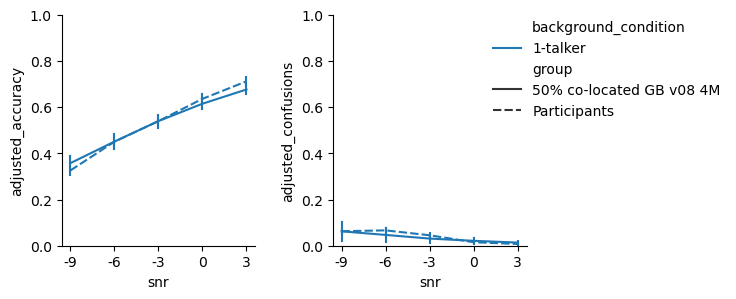

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(6,3))

g = sns.lineplot(data=sex_cond_df, x = 'snr', y = 'adjusted_accuracy', err_style='bars', errorbar=('se', 1),
                  style='group', #style_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'], 
                  hue='background_condition', #palette=palette,
            ax=axs[0])

g1 = sns.lineplot(data=sex_cond_df, x = 'snr', y = 'adjusted_confusions',  err_style='bars', errorbar=('se', 1),
                   style='group', # style_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'], 
                   hue='background_condition',# palette=palette,
            ax=axs[1])

g.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticks(ticks=x_tick_locs) # set new labels
g.set_xticklabels(labels=x_tick_labels)
g1.set_xticklabels(labels=x_tick_labels)
g.set_ylim(0,1)
g1.set_ylim(0,1)
g.legend().remove()     
# add space between plots
plt.subplots_adjust(wspace=0.4)
sns.despine()

# remove legend titles 
g1.legend_.set_title('')
g1.legend(frameon=False, bbox_to_anchor=(.8, 1), loc=2, borderaxespad=0., title='')


In [ ]:
sex_cond_df['id_subject']

0       50% co-located GB v08 4M
1       50% co-located GB v08 4M
2       50% co-located GB v08 4M
3       50% co-located GB v08 4M
4       5654175604212700054a12b1
                  ...           
2348    668428a50c0739b712c33d17
2349    6685332a4bd40063f0f6a8b6
2350    6685332a4bd40063f0f6a8b6
2351    6685332a4bd40063f0f6a8b6
2352    6685332a4bd40063f0f6a8b6
Name: id_subject, Length: 2353, dtype: object

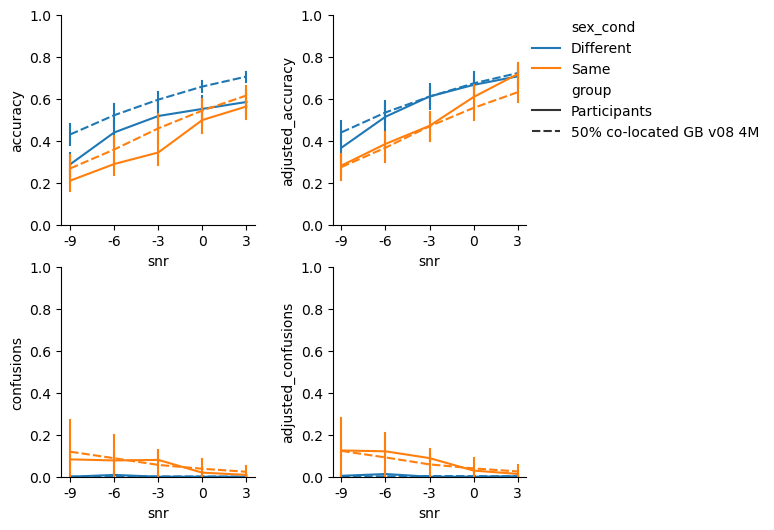

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(6,6))

# style order with participants first 
style_order = ['Participants', '50% co-located GB v08 4M']

g = sns.lineplot(data=sex_cond_df, x = 'snr', y = 'accuracy', err_style='bars', errorbar=('se', 2),
                  style='group', style_order=style_order, 
                  hue='sex_cond',
            ax=axs[0,0])

g1 = sns.lineplot(data=sex_cond_df, x = 'snr', y = 'adjusted_accuracy',  err_style='bars', errorbar=('se', 2),
                   style='group', style_order=style_order, 
                  hue='sex_cond',
            ax=axs[0,1])
g2 = sns.lineplot(data=sex_cond_df, x = 'snr', y = 'confusions', err_style='bars', errorbar=('se', 2),
                  style='group', style_order=style_order, 
                  hue='sex_cond',
            ax=axs[1,0])

g3 = sns.lineplot(data=sex_cond_df, x = 'snr', y = 'adjusted_confusions',  err_style='bars', errorbar=('se', 2),
                   style='group', style_order=style_order, 
                  hue='sex_cond',
            ax=axs[1,1])

g.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticks(ticks=x_tick_locs) # set new labels
g.set_xticklabels(labels=x_tick_labels)
g1.set_xticklabels(labels=x_tick_labels)
g2.set_xticks(ticks=x_tick_locs) # set new labels
g3.set_xticks(ticks=x_tick_locs) # set new labels
g2.set_xticklabels(labels=x_tick_labels)
g3.set_xticklabels(labels=x_tick_labels)
g.set_ylim(0,1)
g1.set_ylim(0,1)
g2.set_ylim(0,1)
g3.set_ylim(0,1)
g.legend().remove()     
g2.legend().remove()     
g3.legend().remove()     
# add space between plots
plt.subplots_adjust(wspace=0.4)
sns.despine()
# remove legend titles 

g1.legend_.set_title('')
g1.legend(frameon=False, bbox_to_anchor=(1, 1), loc=2, borderaxespad=0., title='')


Text(0.5, 0.98, 'Effect of target gender on 1-talker same-gender distractor performance')

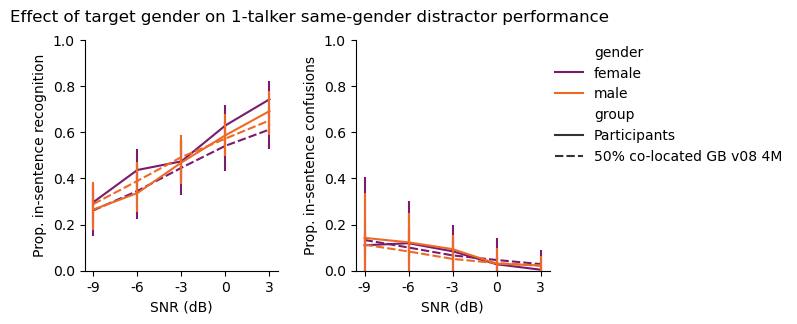

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(6,3))

style_order = ['Participants', '50% co-located GB v08 4M']

to_plot = sex_cond_df[(sex_cond_df.sex_cond == 'Same') ]

g = sns.lineplot(data=to_plot, x = 'snr', y = 'adjusted_accuracy', err_style='bars', errorbar=('se', 2),
                  style='group', style_order=style_order, 
                  hue='gender',palette='inferno',
            ax=axs[0])

g1 = sns.lineplot(data=to_plot, x = 'snr', y = 'adjusted_confusions',  err_style='bars', errorbar=('se', 2),
                   style='group',style_order=style_order, 
                  hue='gender', palette='inferno',
            ax=axs[1])


g.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticks(ticks=x_tick_locs) # set new labels
g.set_xticklabels(labels=x_tick_labels)
g1.set_xticklabels(labels=x_tick_labels)

g.set_ylim(0,1)
g1.set_ylim(0,1)

g.legend().remove()     
# g3.legend().remove()     
# add space between plots
plt.subplots_adjust(wspace=.4)
axs[0].set_xlabel("SNR (dB)")
axs[1].set_xlabel("SNR (dB)")

axs[0].set_ylabel("Prop. in-sentence recognition")
axs[1].set_ylabel("Prop. in-sentence confusions")
sns.despine()
# remove legend titles 
# g.legend(frameon=False, bbox_to_anchor=(1, 1), loc=2, borderaxespad=0., title='')
g1.legend(frameon=False, bbox_to_anchor=(1, 1), loc=2, borderaxespad=0.)

plt.suptitle("Effect of target gender on 1-talker same-gender distractor performance")

50% co-located GB v08 4M


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

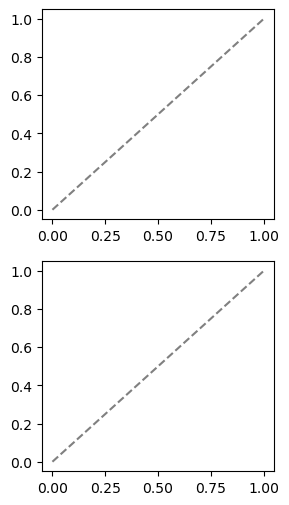

In [ ]:


# plt_name_dict = {'Binaural CV no aug 50% co-located': "Best binaural model", "25% co-located LN last valid time no affine":"New layer ordering", 'Binaural v08': 'New binaural model'}
for_scatter = combined_f0_df.groupby(['background_condition', 'snr', 'group', 'gender_cond', 'target_gender']).agg(
	{'adjusted_accuracy':['mean', 'sem'], 'adjusted_confusions':['mean', 'sem']}).reset_index()
# flatten multi index
for_scatter.columns = ['background_condition', 'snr', 'group', 'gender_cond', 'target_gender', 
						'adjusted_accuracy', 'adj_acc_std_error', "adjusted_confusions", "adj_conf_std_error"]

to_plot = for_scatter[for_scatter.gender_cond == 'same'].copy() #[gender_cond_df.group.isin(list(plt_name_dict.keys()) + [""])]
hue_keys = to_plot.target_gender.unique()
# to_plot.rename(columns={'target_gender': 'talker gender'}, inplace=True)


palette = dict(zip(hue_keys, sns.color_palette("inferno", n_colors= len(hue_keys))))

x = y = np.linspace(0,1,5)

fontsize = 10

# model_list = ["Binaural CommonVoice", "Binaural Half-CoLocated CV", 'Mono CommonVoice', 'Diotic CommonVoice', 'Mono WordSpeakerNoise']
# model_list = to_plot.group.unique()[1:]
# model_list = ['Binaural v08']#, "25% co-located LN last valid time no affine"]

# model_list =  ['70% same-sex distractor'] #["v08 25% co-located"]
# model_list = ["25% co-located LN last valid time no affine"]

n_models = len(model_list)
fig, axs = plt.subplots(2, n_models, figsize=(3 * n_models, 6 ))


# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for ax in axs.flat:
    ax.plot(x,y, ls='dashed', color='grey')

human_df = to_plot[to_plot.group == f'participants']
hue_order = ['male', 'female']


for ix, model in enumerate(model_list):
    print(model)
    
    model_df = to_plot[to_plot.group == model]
    # summarize model data

    for condition in hue_order:
        # print(condition)
        # plot acc 
        human_data = human_df[human_df.target_gender == condition]
        human_means = human_data["adjusted_accuracy"].values
        human_errors = human_data["adj_acc_std_error"].values

        model_data = model_df[model_df.target_gender == condition]
        model_means = model_data["adjusted_accuracy"].values
        model_errors = model_data["adj_acc_std_error"].values
        
        # mult error by 2 for 2 sem 
        axs[0, ix].errorbar(x=human_means, y=model_means, xerr=human_errors*2, yerr=model_errors*2, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= condition,
                             color=palette[condition])#, mfc=palette[condition], mec=palette[condition])
        
        # human confs 
        human_conf_means = human_data["adjusted_confusions"].values
        human_conf_errors = human_data["adj_conf_std_error"].values

        # model adjusted_confusions
        model_conf_means = model_data["adjusted_confusions"].values
        model_conf_errors = model_data["adj_conf_std_error"].values

        axs[1, ix].errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors*2, yerr=model_conf_errors*2, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                               color=palette[condition] )
    
    axs[0,ix].set_title(model, fontsize=fontsize)

    # Add error annotations 
    # acc errors 
    res = stats.spearmanr(human_df["adjusted_accuracy"].values,  model_df['adjusted_accuracy'].values)
    rho = res.correlation
    axs[0, ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    samp_rmse = np.sqrt(np.mean((human_df["adjusted_accuracy"].values - model_df['adjusted_accuracy'].values)**2))
    axs[0, ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)
    # conf errors
    res = stats.spearmanr(human_conf_means, model_conf_means)
    rho = res.correlation
    axs[1, ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    samp_rmse = np.sqrt(np.mean((human_conf_means - model_conf_means)**2))
    axs[1, ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
#         axs[0].set_title(plt_name_dict[model], fontsize=fontsize)
    axs[0, ix].set_xlabel(f"Human prop. correct", fontsize=fontsize)
    axs[1, ix].set_xlabel(f"Human prop. confusions", fontsize=fontsize)

    
# set first row x and y limits to 0 1
for ax in axs.flat:
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

axs[0,0].set_ylabel(f"Model prop. correct", fontsize=fontsize)
axs[1,0].set_ylabel(f"Model prop. confusions", fontsize=fontsize)


sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0,0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(hspace=0.3)

fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3,
           title='Shared talker sex',  bbox_to_anchor=(0.65, 0),)
# plt.tight_layout()
# 

# plt.suptitle(f"Binaural model match to human performance using in-sentence scoring", y=0.95)



In [ ]:

gender_cond_df = (combined_f0_df.groupby(["background_condition", "snr", 'group', "gender_cond"])
                     .agg({"accuracy":"mean",
                           'confusions':'mean', 
                           "adjusted_accuracy":["mean", "sem"],
                           "adjusted_confusions": ["mean", "sem"]})
                     .reset_index())

gender_cond_df.columns = ['background_condition','snr', "group", "gender_cond",
                          'accuracy_mean', 'confusions_mean',
                           'adjusted_accuracy', 'adj_acc_std_error',
                           'adjusted_confusions', 'adj_conf_std_error']



50% co-located GB v08 4M
50% co-located v07
50% co-located v08 4M
Baseline CNN
Standard v08


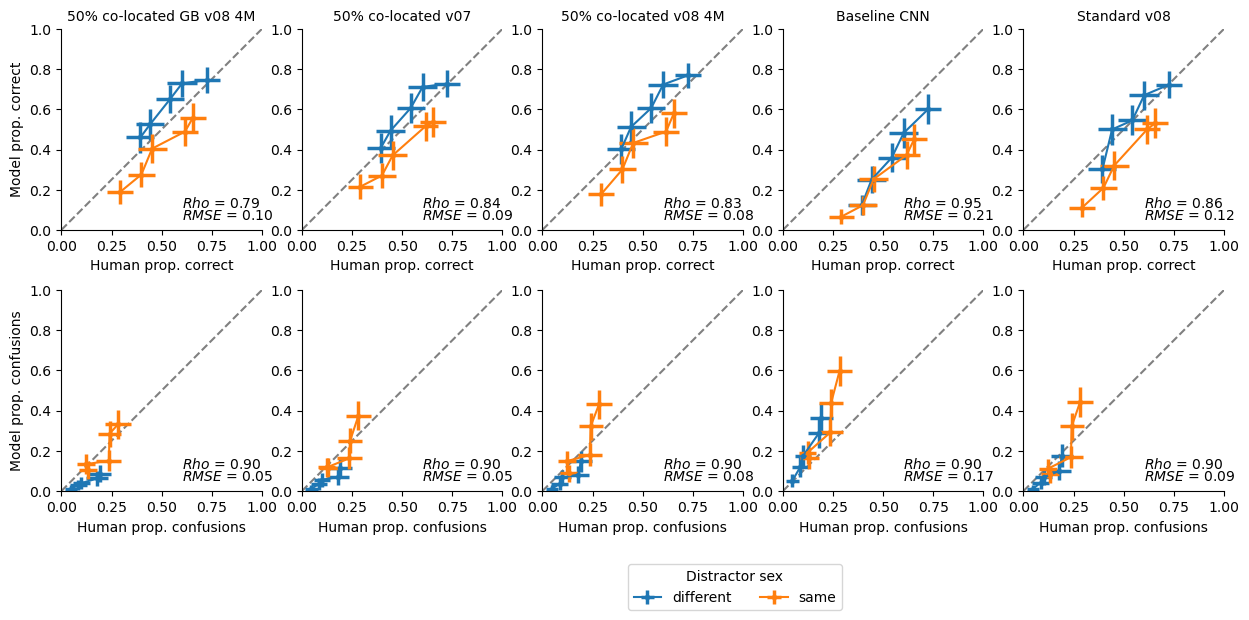

In [ ]:


# plt_name_dict = {'Binaural CV no aug 50% co-located': "Best binaural model", "25% co-located LN last valid time no affine":"New layer ordering", 'Binaural v08': 'New binaural model'}


to_plot = gender_cond_df#[gender_cond_df.group.isin(list(plt_name_dict.keys()) + [""])]
model_list = to_plot.group.unique()[:-1]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

x = y = np.linspace(0,1,5)

fontsize = 10

# model_list = ["Binaural CommonVoice", "Binaural Half-CoLocated CV", 'Mono CommonVoice', 'Diotic CommonVoice', 'Mono WordSpeakerNoise']
# model_list = to_plot.group.unique()[1:]
# model_list = ['Binaural v08']#, "25% co-located LN last valid time no affine"]

# model_list =  ['70% same-sex distractor'] #["v08 25% co-located"]
# model_list = ["25% co-located LN last valid time no affine"]

n_models = len(model_list)
fig, axs = plt.subplots(2, n_models, figsize=(3 * n_models, 6 ))


# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for ax in axs.flat:
    ax.plot(x,y, ls='dashed', color='grey')

human_df = to_plot[to_plot.group == f'participants']
hue_order = ['different', 'same']


for ix, model in enumerate(model_list):
    print(model)
    
    model_df = to_plot[to_plot.group == model]
    # summarize model data

    for condition in hue_order:
        # print(condition)
        # plot acc 
        human_data = human_df[human_df.gender_cond == condition]
        human_means = human_data["adjusted_accuracy"].values
        human_errors = human_data["adj_acc_std_error"].values

        model_data = model_df[model_df.gender_cond == condition]
        model_means = model_data["adjusted_accuracy"].values
        model_errors = model_data["adj_acc_std_error"].values
        
        # mult error by 2 for 2 sem 
        axs[0, ix].errorbar(x=human_means, y=model_means, xerr=human_errors*2, yerr=model_errors*2, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= condition,
                            )#, mfc=palette[condition], mec=palette[condition])
        
        # human confs 
        human_conf_means = human_data["adjusted_confusions"].values
        human_conf_errors = human_data["adj_conf_std_error"].values

        # model adjusted_confusions
        model_conf_means = model_data["adjusted_confusions"].values
        model_conf_errors = model_data["adj_conf_std_error"].values

        axs[1, ix].errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors*2, yerr=model_conf_errors*2, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                                )
    
    axs[0,ix].set_title(model, fontsize=fontsize)

    # Add error annotations 
    # acc errors 
    res = stats.spearmanr(human_df["adjusted_accuracy"].values,  model_df['adjusted_accuracy'].values)
    rho = res.correlation
    axs[0, ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    samp_rmse = np.sqrt(np.mean((human_df["adjusted_accuracy"].values - model_df['adjusted_accuracy'].values)**2))
    axs[0, ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)
    # conf errors
    res = stats.spearmanr(human_conf_means, model_conf_means)
    rho = res.correlation
    axs[1, ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    samp_rmse = np.sqrt(np.mean((human_conf_means - model_conf_means)**2))
    axs[1, ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
#         axs[0].set_title(plt_name_dict[model], fontsize=fontsize)
    axs[0, ix].set_xlabel(f"Human prop. correct", fontsize=fontsize)
    axs[1, ix].set_xlabel(f"Human prop. confusions", fontsize=fontsize)

    
# set first row x and y limits to 0 1
for ax in axs.flat:
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

axs[0,0].set_ylabel(f"Model prop. correct", fontsize=fontsize)
axs[1,0].set_ylabel(f"Model prop. confusions", fontsize=fontsize)


sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0,0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(hspace=0.3)

fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3,
           title='Distractor sex',  bbox_to_anchor=(0.65, 0),)
# plt.tight_layout()
# 

# plt.suptitle(f"Binaural model match to human performance using in-sentence scoring", y=0.95)

